# High prevalence of antibiotic resistance of Streptococcus species in saliva from non-hospitalized adults – a continuation of the study

In [ ]:
# ── Setup: install missing packages (run once) ───────────────────────────────
# install.packages(c("readxl", "tidyverse", "ggplot2", "pheatmap", "patchwork",
#                    "RColorBrewer", "ggnewscale", "rentrez", "ggalluvial",
#                    "ape", "ggtree", "ggtreeExtra", "vegan", "writexl",
#                    "phytools", "gridExtra"))

# ── Libraries ────────────────────────────────────────────────────────────────
library(readxl)
library(tidyverse)
library(ggplot2)
library(readr)
library(stringr)
library(pheatmap)
library(purrr)
library(tibble)
library(patchwork)
library(RColorBrewer)
library(ggnewscale)
library(rentrez)
library(ggalluvial)
library(ape)
library(ggtree)
library(ggtreeExtra)
library(vegan)
library(phytools)
library(gridExtra)
library(grid)
library(writexl)


### Metadata preparation

In [ ]:
df = read_excel("strepseq_master_sheet.xlsx")
dim(df)
colnames(df)
head(df)

In [ ]:
# How many included in the original paper
table(df$Included_in_PMID_40182115)

# Resistance counts
table(df$Resistance)
sum(is.na(df$Resistance))

# How many have zone diameter data
sum(!is.na(df$`Zone diameter`) & df$`Zone diameter` != " ")

In [ ]:
zone_stats <- df %>%
  transmute(
    Resistance = str_trim(as.character(Resistance)),
    Zone_diameter_raw = as.character(`Zone diameter`)
  ) %>%
  mutate(
    # Extract antibiotic name from values like "Clindamycin_resistant"
    antibiotic = str_remove(Resistance, "_resistant$") %>% str_to_lower(),
    # Parse zone diameter safely (handles text/units; convert comma decimals)
    zone_diameter = parse_number(str_replace_all(Zone_diameter_raw, ",", "."))
  ) %>%
  filter(!is.na(antibiotic), antibiotic != "", !is.na(zone_diameter)) %>%
  group_by(antibiotic) %>%
  summarise(
    n = n(),
    min_zone_diameter = min(zone_diameter),
    max_zone_diameter = max(zone_diameter),
    .groups = "drop"
  ) %>%
  arrange(antibiotic)

zone_stats

96 samples and 20 columns.

Columns used in future analysis:

SAMPLE_ID  
GM_FILE_ID

__QUALITY CONTROL__

*Genome_sequencing_qc*
Quality control status of genome sequencing (Pass/Fail).

*Number_contigs_genome*
Number of contigs in the assembled genome. Lower numbers = better assembly quality.

*Genome_size*
Total assembled genome length. Useful for detecting outliers or contamination.

__SPECIES IDENTIFICATION__

*Species_GTDB_release207_ANIpercent*
Species assignment based on GTDB taxonomy (release 207) using ANI comparison. Includes both species name and ANI percentage indicating similarity to reference.

*Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc*
Antimicrobial resistance genes detected using Abricate with the ResFinder database (version 2019-09-10), with 60% coverage and 90% identity. In the future this will be rerun with a newer version of the database. 

*Exlcude_due_to_uncertainty_about_sample_identity*
Flag KEEP/EXCLUDE.

*Maldi species 2. test*
Species identification result from a second MALDI-TOF run done after initial MALDI-TOF run, after performing isolation protocol in the lab.


__AR__

*Resistance*
Phenotypic resistance classification (Clindamycin_resistant, Ampicillin_resistant, Penicillin_resistant). 

In [ ]:
df |> filter((Genome_sequencing_qc == "Fail") |
                            Exlcude_due_to_uncertainty_about_sample_identity == "EXCLUDE") 

In [ ]:
# keep only relevant columns

df_filtered <- df |> select(c('SAMPLE_ID','GM_FILE_ID','Genome_sequencing_qc',
                            'Number_contigs_genome','Genome_size','Species_GTDB_release207_ANIpercent',
                            'Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc',
                            'Exlcude_due_to_uncertainty_about_sample_identity',
                            'Resistance','Maldi species 2. test', 'Zone diameter')) |>

                    filter((Genome_sequencing_qc == "Pass") & 
                            Exlcude_due_to_uncertainty_about_sample_identity == "KEEP") |>

                    select(-c(Genome_sequencing_qc, 
                            Exlcude_due_to_uncertainty_about_sample_identity))

dim(df_filtered)
head(df_filtered)


In [ ]:
# stats

assembly_metrics <- df_filtered %>%
  transmute(
    contigs = parse_number(as.character(Number_contigs_genome)),
    genome_size = parse_number(as.character(Genome_size))
  ) %>%
  summarise(
    n_samples = n(),
    contigs_min = min(contigs, na.rm = TRUE),
    contigs_max = max(contigs, na.rm = TRUE),
    contigs_avg = mean(contigs, na.rm = TRUE),
    genome_size_min = min(genome_size, na.rm = TRUE),
    genome_size_max = max(genome_size, na.rm = TRUE),
    genome_size_avg = mean(genome_size, na.rm = TRUE)
  )

assembly_metrics

89 samples remain for further analysis, 7 removed due to low quality, contamination or duplication with another sample.

### Check between GTDB releases 207 - 214 - 226

In [ ]:
# helpers
extract_strep_species <- function(classification) {
  classification |>
    str_extract("s__Streptococcus [^;]+") |>
    str_remove("s__Streptococcus ") |>
    str_trim() |>
    na_if("") |>
    replace_na("no species")                         # convert empty strings to NA
    
}

read_gtdb_file <- function(filepath, version_name) {
  read_delim(filepath, delim = "\t", show_col_types = FALSE, trim_ws = TRUE) |>
    transmute(
      user_genome = str_trim(user_genome),
      !!paste0("species_", version_name) := extract_strep_species(classification)
    )
}

# read
gtdb_207 <- read_gtdb_file("gdtb_names/gtdbtk_207.tsv", "207")
gtdb_214 <- read_gtdb_file("gdtb_names/gtdbtk_214.tsv", "214")

gtdb_226 <- read_tsv(
    "gdtb_names/gtdbtk_226.tsv",
    show_col_types = FALSE,
    na = c("", "NA", "N/A")
  ) |>
  transmute(
    user_genome = str_trim(user_genome),
    species_226 = str_trim(species)
  ) |>
  mutate(species_226 = replace_na(species_226, "no species"))

# apply filtering 
valid_ids <- df_filtered |>
  transmute(user_genome = str_trim(as.character(GM_FILE_ID))) |>
  distinct()

gtdb_207_qc <- gtdb_207 |> semi_join(valid_ids, by = "user_genome")
gtdb_214_qc <- gtdb_214 |> semi_join(valid_ids, by = "user_genome")
gtdb_226_qc <- gtdb_226 |> semi_join(valid_ids, by = "user_genome")

# combine
gtdb_comparison <- gtdb_207_qc |>
  inner_join(gtdb_214_qc, by = "user_genome") |>
  inner_join(gtdb_226_qc, by = "user_genome")




# only mismatches
gtdb_mismatches <- gtdb_comparison |>
  filter(!(species_207 == species_214 & species_214 == species_226))

gtdb_mismatches_207_214 <- gtdb_comparison |>
  filter(!(species_207 == species_214))

cat("Total genomes in all 3 releases:", nrow(gtdb_comparison), "\n")
cat("Mismatches:", nrow(gtdb_mismatches), "\n")
cat("Mismatches 207-214:", nrow(gtdb_mismatches_207_214), "\n")

# save file
write_tsv(gtdb_mismatches, "gdtb_names/gtdb_species_mismatches_qc.tsv")

gtdb_mismatches_207_214

gtdb_comparison |> filter(species_207 == "no species")

Since in further analysis we will be comparing these genomes with genomes from All The Bacteria database, which uses the taxonomy from GTDB release 214, I will also proceed with using the species identification from that release, to make the most accurate comparison possible.

### GDTB 207 vs MALDI-tof run 2 species comparison

In [ ]:
# df from 214 names + df_filtered

df_filtered <- df_filtered |>
  select(-matches("^species_214")) |>
  left_join(
    gtdb_214_qc |>
      distinct(user_genome, .keep_all = TRUE) |>
      select(user_genome, species_214),
    by = c("GM_FILE_ID" = "user_genome")
  )

species_df <- df_filtered |>
  select(
    SAMPLE_ID,
    Resistance,
    Maldi_2 = `Maldi species 2. test`,
    GTDB_214 = species_214
  ) |>
  mutate(
    Maldi_2 = str_to_lower(str_trim(Maldi_2))
  )

sample_n(species_df, 5)

__Species distribution__

In [ ]:
# GTDB_207

species_df |>
    count(GTDB_214, sort = TRUE) |>
    ggplot(aes(x = reorder(GTDB_214, n), y = n)) +
    geom_col(fill = "dark green") +
    coord_flip() +
    labs(title = "GTDB species distribution", x = NULL, y = "Count") +
    theme_minimal()


# Maldi_2

species_df |>
    count(Maldi_2, sort = TRUE) |>
    ggplot(aes(x = reorder(Maldi_2, n), y = n)) +
    geom_col(fill = "purple") +
    coord_flip() +
    labs(title = "Maldi_2 species distribution", x = NULL, y = "Count") +
    theme_minimal()



##### Matches and mismatches between GDTB and Maldi 2 results

In [ ]:


species_df <- species_df |>
  mutate(
    match_status = case_when(
      GTDB_214 == "no species" ~ "unknown",
      GTDB_214 == Maldi_2 ~ "match",   # exact match only
      TRUE ~ "mismatch"
    )
  )

species_df |> count(match_status)

head(species_df)

In [ ]:
# mismatch counts
mismatch_counts <- species_df |>
  filter(match_status == "mismatch") |>
  count(GTDB_214, Maldi_2, sort = TRUE) |>
  mutate(pair = paste(Maldi_2, "→", GTDB_214))

# match counts
match_counts <- species_df |>
  filter(match_status == "match") |>
  count(GTDB_214, Maldi_2, sort = TRUE) |>
  mutate(pair = paste(Maldi_2, "→", GTDB_214))

# unknown counts
unknown_counts <- species_df |>
  filter(match_status == "unknown") |>
  count(GTDB_214, Maldi_2, sort = TRUE) |>
  mutate(pair = paste(Maldi_2, "→", GTDB_214))

# combined
combined_counts <- bind_rows(
  mismatch_counts |> mutate(status = "mismatch"),
  match_counts |> mutate(status = "match"),
  unknown_counts |> mutate(status = "unknown")
)

#combined_counts

# faceted plot with wider dimensions
ggplot(combined_counts, aes(x = reorder(pair, n), y = n, fill = status)) +
  geom_col() +
  geom_text(aes(label = n), hjust = -0.2, size = 3) +
  coord_flip() +
  facet_wrap(~status, scales = "free_y", nrow = 1) +
  scale_fill_manual(values = c("match" = "green", "mismatch" = "red", "unknown" = "gray")) +
  labs(title = "Species Comparison: GTDB vs MALDI-TOF", 
       x = "Species Pair (MALDI → GTDB)", 
       y = "Count") +
  theme_minimal() +
  theme(legend.position = "none")


# all match statuses together
ggplot(combined_counts, aes(x = reorder(pair, n), y = n, fill = status)) +
  geom_col() +
  geom_text(aes(label = n), hjust = -0.2, size = 3) +
  coord_flip() +
  scale_fill_manual(values = c("match" = "green", "mismatch" = "red", "unknown" = "gray")) +
  labs(title = "Species Comparison: GTDB vs MALDI-TOF", 
       x = "Species Pair (GTDB → MALDI)", 
       y = "Count",
       fill = "Status") +
  theme_minimal() +
  theme(legend.position = "top")



In [ ]:
# larger canvas
options(repr.plot.width = 16, repr.plot.height = 12) #repr.plot.res = 140)
theme_set(theme_minimal(base_size = 16))

sankey_df <- species_df |>
  count(Maldi_2, GTDB_214, match_status, name = "n") |>
  filter(!is.na(Maldi_2), !is.na(GTDB_214))

# old alphabetical ordering kept here for reference
# maldi_levels <- sankey_df |>
#   distinct(Maldi_2) |>
#   arrange(Maldi_2) |>
#   pull(Maldi_2)
#
# gtdb_levels <- sankey_df |>
#   distinct(GTDB_214) |>
#   arrange(GTDB_214) |>
#   pull(GTDB_214)

# order by clustering to reduce crossings
flow_mat <- sankey_df |>
  select(Maldi_2, GTDB_214, n) |>
  tidyr::pivot_wider(
    names_from = GTDB_214,
    values_from = n,
    values_fill = 0
  ) |>
  tibble::column_to_rownames("Maldi_2") |>
  as.matrix()

maldi_levels <- if (nrow(flow_mat) > 1) {
  rownames(flow_mat)[hclust(dist(flow_mat))$order]
} else {
  rownames(flow_mat)
}

gtdb_levels <- if (ncol(flow_mat) > 1) {
  colnames(flow_mat)[hclust(dist(t(flow_mat)))$order]
} else {
  colnames(flow_mat)
}

sankey_df <- sankey_df |>
  mutate(
    Maldi_2 = factor(Maldi_2, levels = maldi_levels),
    GTDB_214 = factor(GTDB_214, levels = gtdb_levels),
    Maldi_2_num = as.numeric(Maldi_2),
    GTDB_214_num = as.numeric(GTDB_214)
  )

# Create lookup vectors
maldi_lookup <- setNames(as.character(maldi_levels), seq_along(maldi_levels))
gtdb_lookup <- setNames(as.character(gtdb_levels), seq_along(gtdb_levels))

ggplot(
  sankey_df,
  aes(axis1 = Maldi_2_num, axis2 = GTDB_214_num, y = n)
) +
  geom_alluvium(
    aes(fill = match_status),
    width = 1/14,
    alpha = 0.85,
    knot.pos = 0.35,
    colour = "white",
    linewidth = 0.5
  ) +
  geom_stratum(width = 1/12, fill = "grey90", color = "grey40") +
  geom_text(
    stat = "stratum",
    aes(label = after_stat(
      ifelse(x == 1,
             maldi_lookup[stratum],
             gtdb_lookup[stratum])
    )),
    size = 3,
    check_overlap = FALSE
  ) +
  scale_x_continuous(breaks = c(1, 2), labels = c("MALDI-TOF (run 2)", "GTDB r214"), expand = c(0.24, 0.24)) +
  scale_y_continuous(expand = expansion(mult = c(0.03, 0.08))) +
  scale_fill_manual(values = c("match" = "green", "mismatch" = "red", "unknown" = "gray")) +
  labs(
    title = "Sankey plot: MALDI-TOF vs GTDB species assignment",
    y = "Count",
    fill = "Status"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.title.x = element_blank(),
    legend.position = "top",
    plot.title = element_text(size = 18, face = "bold"),
    plot.margin = margin(10, 50, 10, 50)
  )

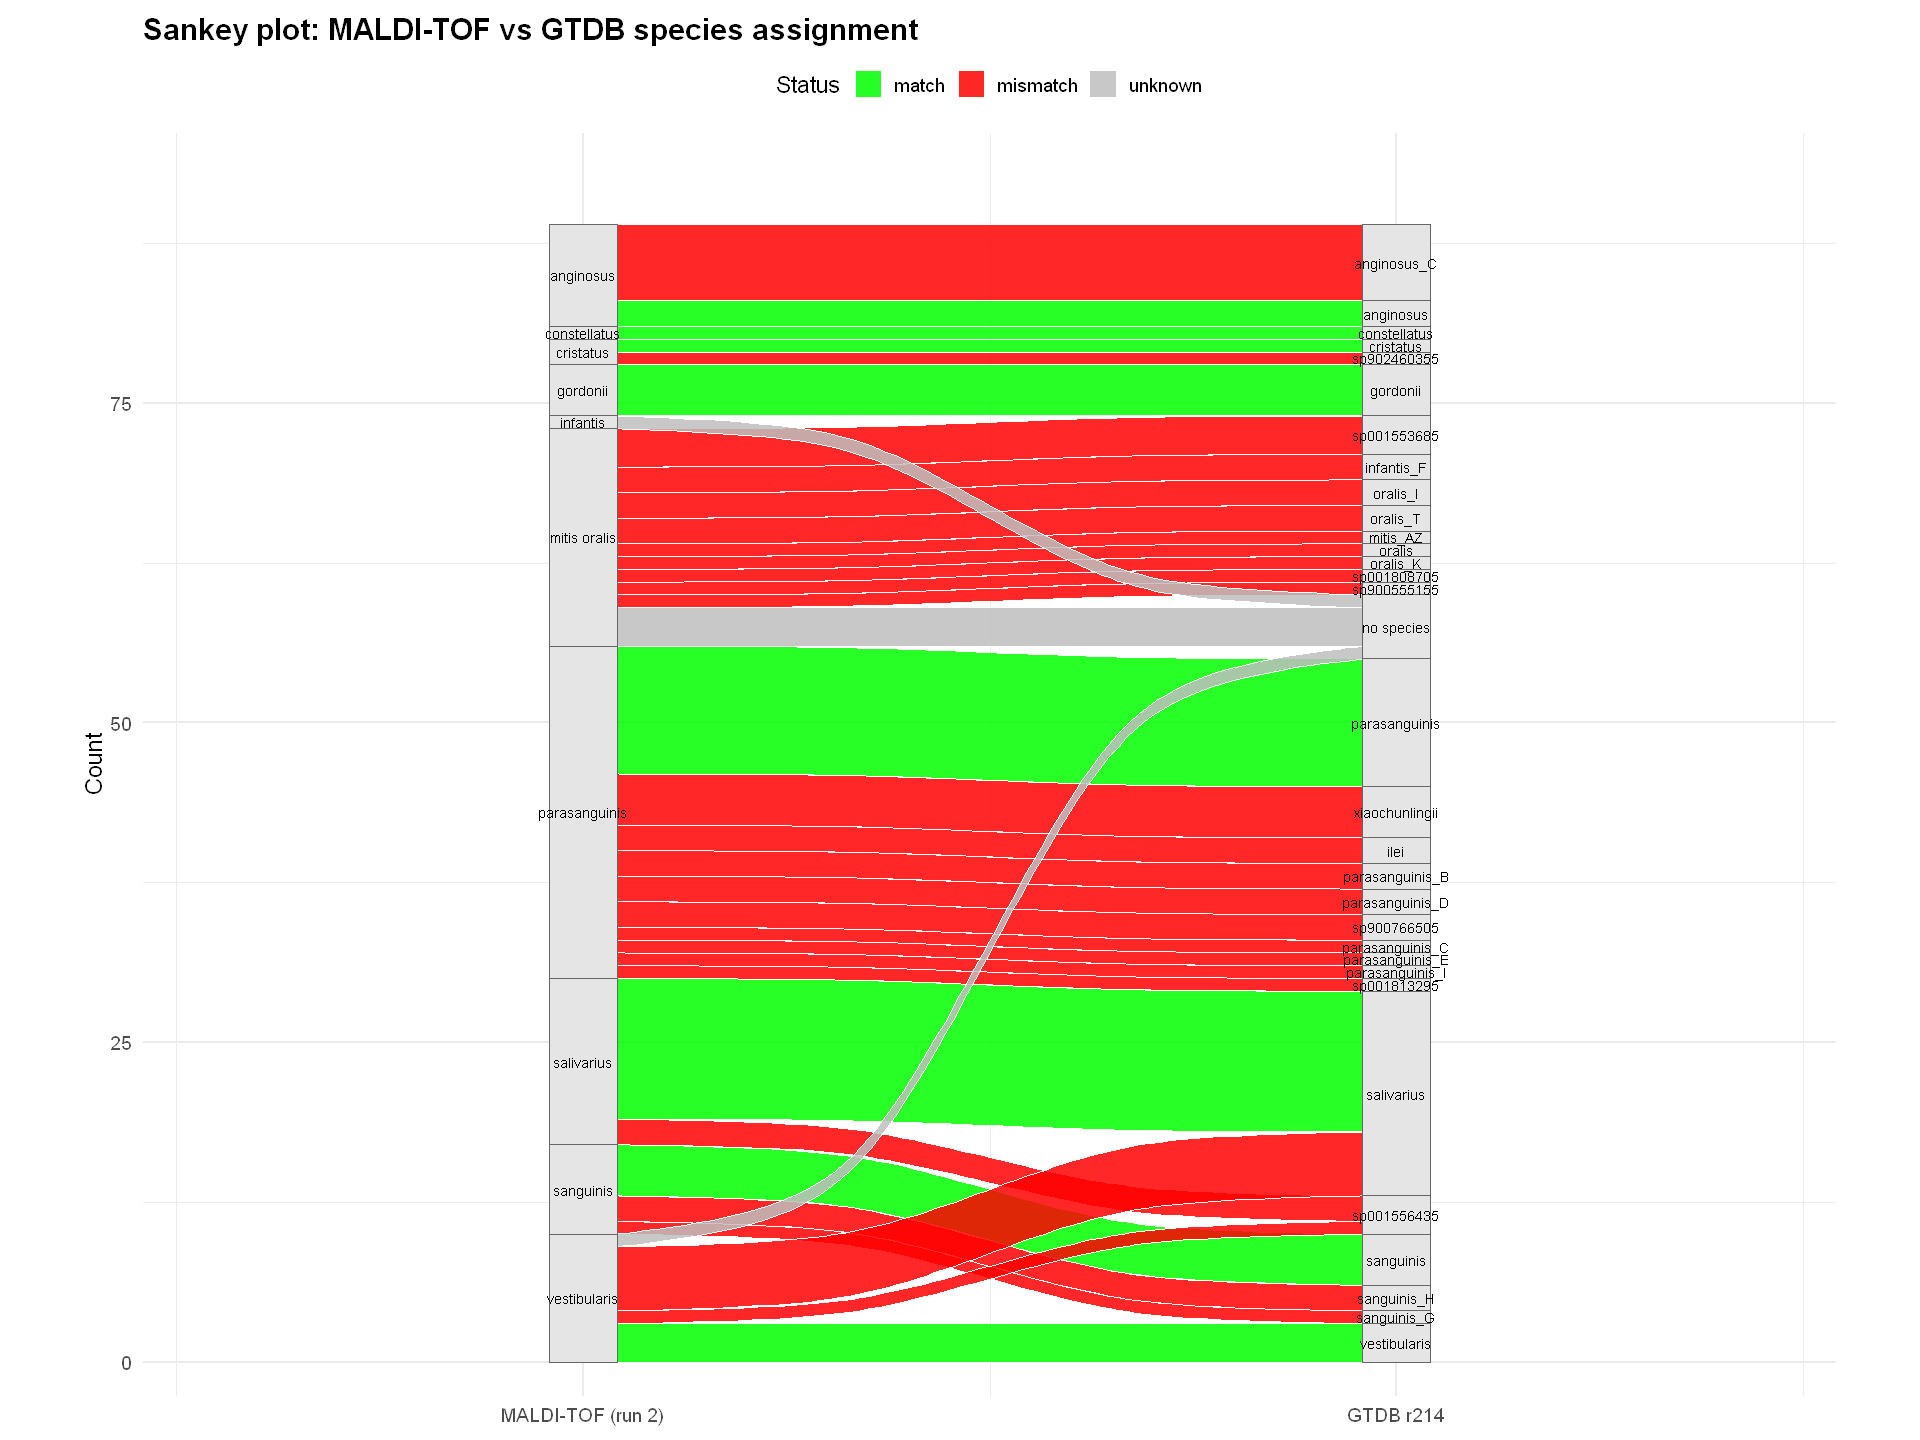


The Sankey plot shows that agreement between MALDI-TOF (run 2) and GTDB r214 is strongly species-dependent.

The clearest concordance is seen where the largest flow from a MALDI label maps to the same GTDB species (for example, major self-mapping is visible for parasanguinis and salivarius). However, several MALDI labels also split into multiple GTDB taxa, indicating discordant assignments.

The largest discordance is for the MALDI label **“mitis oralis”**, which is distributed across multiple GTDB groups (including oralis/mitis-related labels and several placeholder taxa). This pattern is consistent with known difficulty in resolving closely related Streptococcus taxa using MALDI-TOF and with taxonomic granularity differences between methods.

A subset of isolates maps to **“no species”** in GTDB (shown as gray/unknown), reflecting cases without confident species-level GTDB assignment.

Overall, the figure supports partial agreement between methods, with good concordance for some common labels and substantial splitting for closely related taxa.



## Antibiotic resistance

AMRFinder is the main tool.

Antimicrobial resistance gene identification will be run using ResFinder and AMRFinderPlus with all 96 genomes.

Detection thresholds are set to minimum 90% (or default of the gene) nucleotide identity and 50% gene coverage, which are the default settings for AMRFinder.

https://github.com/ncbi/amr/wiki/Running-AMRFinderPlus#usage :  
--ident_min <0-1> or -i <0-1> Minimum identity for a blast-based hit hit (Methods BLAST or PARTIAL). -1 means use the curated threshold if it exists and 0.9 otherwise. Setting this value to something other than -1 will override curated similarity cutoffs. We only recommend using this option if you have a specific reason; don't make our curators sad by throwing away some of their hard work.





papers to cite / look at:
AMRFinder and ResFinder thresholds:

https://pubmed.ncbi.nlm.nih.gov/31427293/


https://www.thelancet.com/journals/lanmic/article/PIIS2666-5247(24)00152-6/fulltext

The thresholds in
https://pmc.ncbi.nlm.nih.gov/articles/PMC9598756/#sec4-antibiotics-11-01400 are:

"ResFinder for acquired AMR genes, with default settings of 90% nucleotide similarity and a 60% minimum length.
AMRFinder with minimum BLAST identity cut-off of >90% and >50% alignment coverage."

However, for ResFinder, they cite this paper https://pmc.ncbi.nlm.nih.gov/articles/PMC7662176/ , in which it says:

"WGS data (FASTQ) were used as input for ResFinder 4.0 using default parameters (≥80% identity over ≥60% of the length of the target gene)"

So here it is the default, which is not 0.9! However, they do not compare it with AMRFinder here.


I didn't understand why in ResFinder those would be the default settings, since software default is 0.8 identity/similarity, but I think it might be in previous versions. I didn't find that specification in the documentation of old versions though.

In this guideline on how to do AMR research (it is a little bit old)
 https://www.food.dtu.dk/english/-/media/institutter/foedevareinstituttet/temaer/antibiotikaresistens/eurl-ar/wgs/628_protocol-for-wgs-v2-2.pdf they say:

For acquired antimicrobial resistance genes:
Select all antimicrobial databases (default setting)
 Select threshold for % ID: 90 %
 Select minimum length: 60 %

...

It is also worth noting that AMRFinder uses the curated threshold for the gene, if it exists, and 0.9 identity otherwise, while coverage is always 0.5.

Now that I have overthought this, can I go on and use the settings like in the paper referenced above?
I think ResFinder is okay with 0.9 identity and 0.6 coverage to avoid false positives, while we can keep AMR at 0.5 coverage and default indenity instead. For coverage being lower with AMR my argument would be that it uses a more complex algorithm than ResFinder to avoid innacuracies.

<!-- TODO: UPDATE: Just use default settings. whatever -->


### ResFinder 4.7.2

script:

        
       #!/bin/bash
        #SBATCH --job-name=resfinder_strep
        #SBATCH --array=1-96
        #SBATCH --cpus-per-task=4
        #SBATCH --mem=8G
        #SBATCH --time=02:00:00
        #SBATCH --output=logs/resfinder_%a.log
        #SBATCH --error=logs/resfinder_%a.err

        #conda initialize
        source /home/ctools/miniconda3/etc/profile.d/conda.sh
        conda activate /home/projects2/strepseq_rmarvig/tools/conda_envs/resfinder2


        # ── paths ────────────────────────────────────────────────────────────────────
        GENOME_DIR=/home/projects2/strepseq_rmarvig/assemblies
        OUT_DIR=/home/projects2/strepseq_rmarvig/results/resfinder_default
        RESFINDER=/home/projects2/strepseq_rmarvig/tools/resfinder2

        # genome N
        GENOME=$(ls $GENOME_DIR/*.fna | sed -n "${SLURM_ARRAY_TASK_ID}p")
        SAMPLE=$(basename $GENOME .fna)

        echo "Running sample: $SAMPLE (job index: $SLURM_ARRAY_TASK_ID)"

        # ── make output folder for this sample ───────────────────────────────────────
        mkdir -p $OUT_DIR/$SAMPLE

        # ── run ResFinder ─────────────────────────────────────────────────────────────
        python3 -m resfinder \
            -ifa $GENOME \
            -o $OUT_DIR/$SAMPLE \
            -s "other" \
            -db_res $RESFINDER/resfinder_db \
            -db_point $RESFINDER/pointfinder_db \
            --acquired \
            --point \
            

failed runs check:

        for dir in /path/to/resfinder_output/*/; do
            [ -f "$dir/ResFinder_results_tab.txt" ] || echo "MISSING: $dir"
        done


there were no failed runs.


**output files** in each of the 96 directories of *resfinder_results* directory:

ResFinder_results_tab.txt	    |    Main tabular results — AMR genes found
ResFinder_results.txt	        |    Detailed alignment results
PointFinder_results.txt	        |    Point mutation results
pheno_table.txt	                |    Predicted phenotypic resistance per antibiotic class

##### Preparation of tabular results

combining tabular results into a final .tsv file:

working directory: */home/projects2/strepseq_rmarvig/results/resfinder_default*

        for dir in ./*/; do
            SAMPLE=$(basename $dir)
            awk -v s="$SAMPLE" 'NR>1{print s"\t"$0}' "$dir/ResFinder_results_tab.txt"
        done > combined_resfinder_results.tsv


add header (first line of results file from first sample):

        head -1 0043m-CMPN001x78_260114_LH00793_B23GCKKLT3/ResFinder_results_tab.txt \
            | awk '{print "Sample\t"$0}' | \
            cat - combined_resfinder_results.tsv > combined_with_header.tsv





##### Preparation of pheno table

        # header
        echo -e "Sample\tAntimicrobial\tClass\tWGS_phenotype\tMatch\tGenetic_background" > combined_pheno.tsv

        # all files
        for dir in */; do
            SAMPLE=$(basename $dir)
            FILE="$dir/pheno_table.txt"
            if [ -f "$FILE" ]; then
                grep -v "^#" "$FILE" | grep -v "^$" | \
                awk -v s="$SAMPLE" '{print s"\t"$0}' >> combined_pheno.tsv
            else
                echo "WARNING: missing $FILE" >&2
            fi
        done




### AMR finder

using amrfinder version 4.2.7: https://github.com/ncbi/amr/wiki

AMRFinder has the option to activate species-specific resistance rules, such as point mutation detection, gene interpretation rules and curated resistance models. The available Streptococcus organisms supported by AMRFinder are:
- Streptococcus_agalactiae
- Streptococcus_pneumoniae
- Streptococcus_pyogenes

None of them have been found among the Streptococcus species in our data.
Therefore I will omit specifying any organism.

script:

        #!/bin/bash
        #SBATCH --job-name=amrfinder_strep
        #SBATCH --array=1-96
        #SBATCH --cpus-per-task=4
        #SBATCH --mem=8G
        #SBATCH --time=02:00:00
        #SBATCH --output=logs/amrfinder_%a.log
        #SBATCH --error=logs/amrfinder_%a.err

        # conda initialize
        source /home/ctools/miniconda3/etc/profile.d/conda.sh
        conda activate /home/projects2/strepseq_rmarvig/tools/conda_envs/amrfinder

        # paths
        GENOME_DIR=/home/projects2/strepseq_rmarvig/assemblies
        OUT_DIR=/home/projects2/strepseq_rmarvig/results/amrfinder_results

        # genome N
        GENOME=$(ls $GENOME_DIR/*.fna | sed -n "${SLURM_ARRAY_TASK_ID}p")
        SAMPLE=$(basename $GENOME .fna)

        echo "Running AMRFinder on: $SAMPLE (job index: $SLURM_ARRAY_TASK_ID)"

        mkdir -p $OUT_DIR
        mkdir -p $OUT_DIR/logs

        # run AMRFinder
        amrfinder \
            --nucleotide $GENOME \
            --threads 4 \
            --output $OUT_DIR/${SAMPLE}_amrfinder.tsv

combine files:

    head -1 $(ls *_amrfinder.tsv | head -1) | \
        awk '{print "Sample\t"$0}' > combined_amrfinder_def.tsv

    for f in *_amrfinder.tsv; do
        SAMPLE=$(basename $f _amrfinder.tsv)
        tail -n +2 "$f" | awk -v s="$SAMPLE" '{print s"\t"$0}'
    done >> combined_amrfinder_def.tsv

### Analysis

##### Load data

NOTE: Quality control filtering was applied above with Genome_sequencing_qc == Pass and Exclude == KEEP.
ResFinder and AMRFinder were both run on all 96 assemblies, but in the analysis below the results are filtered to the 89 kept samples by joining on GM_FILE_ID and automatically dropping excluded samples from further analysis.

2 versions of ResFinder were run. The following analysis uses the results from ResFinder version 4.7.2

In [ ]:
# resfinder pheno table
pheno <- read_tsv("results/combined_pheno_def.tsv", show_col_types = FALSE)

# resfinder raw genes
res <- read_tsv("results/combined_resfinder_default.tsv", show_col_types = FALSE)

#fix amr file
raw_lines <- read_lines("results/combined_amrfinder_def.tsv")
fixed_lines <- str_replace(raw_lines, "^combined\t", "")
write_lines(fixed_lines, "results/combined_amrfinder_def.tsv")

amr <- read_tsv("results/combined_amrfinder_def.tsv", show_col_types = FALSE) |>
    rename_with(~ str_replace_all(., ' ', '_') |> str_to_lower())



cat('pheno rows:', nrow(pheno), '\n')
cat('res rows:  ', nrow(res), '\n')
cat('amr rows:  ', nrow(amr), 'columns:', ncol(amr), '\n')

n_distinct(amr$sample)
n_distinct(res$Sample)

##### Filter to QC-passed samples only



In [ ]:
valid_ids <- df_filtered |> pull(GM_FILE_ID)


pheno_clean <- pheno |> filter(Sample %in% valid_ids)
res_clean   <- res   |> filter(Sample %in% valid_ids)
amr_clean   <- amr   |> filter(sample %in% valid_ids)

cat('Samples in pheno after QC filter:', n_distinct(pheno_clean$Sample), '\n')
cat('Samples in ResFinder after QC filter:', n_distinct(res_clean$Sample), '\n')
cat('Samples in AMRFinder after QC filter:', n_distinct(amr_clean$sample), '\n')

ResFinder's pheno_table.txt outputs phenotypic predictions for every sample, even if no genes were found; it predicts resistance/susceptibility for each antibiotic class based on gene presence - all 89 QC-passed samples have phenotype predictions.

Both gene resistance finders only output rows if they detect a gene match for the sample. 13 samples had no detectable genes. These are likely susceptible to all antibiotics / just tolerant.

#### Phenotypic resistance


In [ ]:

head(df_filtered)
pheno_clean |> filter(WGS_phenotype != "No resistance") |> head()





In [ ]:
pheno_clean |> 
filter(WGS_phenotype != "No resistance") |>
left_join(
    df_filtered |>
    select(GM_FILE_ID, `Zone diameter`, Resistance),
    by = c("Sample" = "GM_FILE_ID")
) |>
  write_tsv("antimicrobial_resistance_output.tsv")


In [ ]:
# library(tidyverse)  # loaded in setup
# library(patchwork)  # loaded in setup

# 1. Data Cleaning
df <- read_tsv("antimicrobial_resistance_output.tsv") %>%
  # Clean Zone Diameter (remove 'R' and handle empty spaces)
  mutate(
    zone_num = as.numeric(str_extract(`Zone diameter`, "\\d+")),
    # Extract clean gene names (e.g., msr(D) from msr(D)_AF274302)
    genes_clean = str_extract_all(Genetic_background, "[a-zA-Z0-9]+\\([A-Z0-9]+\\)|[a-z]{3}[A-Z0-9]+") 
  )

# 2. MDR Calculation (Resistance to >= 3 classes)
mdr_summary <- df %>%
  group_by(Sample) %>%
  summarize(
    resistant_classes = n_distinct(Class[WGS_phenotype == "Resistant"]),
    is_mdr = resistant_classes >= 3
  )

df_mdr <- df %>% left_join(mdr_summary, by = "Sample")

# --- VISUALIZATION 1: Heatmap of Gene presence vs Antimicrobial Resistance ---
# This shows which genes appear most frequently with specific antibiotics
gene_heatmap_data <- df %>%
  unnest(genes_clean) %>%
  count(genes_clean, Antimicrobial)

p1 <- ggplot(gene_heatmap_data, aes(x = Antimicrobial, y = genes_clean, fill = n)) +
  geom_tile(color = "white") +
  scale_fill_viridis_c(name = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Gene vs Antibiotic Resistance Heatmap",
       x = "Antimicrobial Tested", y = "Detected Gene")

# --- VISUALIZATION 2: Phenotypic Resistance (Zone Diameter) by Class ---
# Smaller zone diameter = Higher resistance
p2 <- df_mdr %>%
  filter(!is.na(zone_num)) %>%
  ggplot(aes(x = Class, y = zone_num, fill = Class)) +
  geom_boxplot(alpha = 0.7) +
  geom_jitter(width = 0.1, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Zone Diameter Distribution by Antimicrobial Class",
       subtitle = "Lower values indicate higher phenotypic resistance",
       y = "Zone Diameter (mm)", x = "") +
  theme(legend.position = "none", axis.text.x = element_text(angle = 45, hjust = 1))

# --- VISUALIZATION 3: MDR Status Distribution ---
p3 <- mdr_summary %>%
  count(is_mdr) %>%
  ggplot(aes(x = is_mdr, y = n, fill = is_mdr)) +
  geom_col() +
  scale_fill_manual(values = c("skyblue", "tomato")) +
  theme_minimal() +
  labs(title = "Multi-Drug Resistance (MDR) Summary",
       subtitle = "MDR defined as resistance to 3+ antibiotic classes",
       x = "Is MDR?", y = "Number of Samples")

p1
p2
p3

In [ ]:
mismatches <- df %>%
  mutate(zone_val = as.numeric(str_extract(`Zone diameter`, "\\d+"))) %>%
  filter(WGS_phenotype == "Resistant" & zone_val > 15)

mismatches

##### Genes vs antibiotics

In [ ]:
# Top AMR genes colored by antibiotic class

pheno_resistant <- pheno_clean |>
  filter(WGS_phenotype == 'Resistant')
  
top_genes_by_class <- pheno_resistant |>
  filter(!is.na(Genetic_background), Genetic_background != '') |>
  separate_rows(Genetic_background, sep = ',') |>
  mutate(gene = str_extract(Genetic_background, '^[^\\s(]+') |> str_trim()) |>
  filter(!is.na(gene), gene != '') |>
  distinct(Sample, Class, gene) |>
  count(gene, Class, name = 'n') |>
  group_by(gene) |>
  mutate(total = sum(n)) |>
  ungroup() |>
  slice_max(total, n = 15) |>
  arrange(desc(total))

ggplot(top_genes_by_class, aes(x = reorder(gene, total), y = n, fill = Class)) +
  geom_col() +
  coord_flip() +
  labs(title = 'Top 15 AMR genes by antibiotic class (ResFinder)',
       x = 'Gene', 
       y = 'Number of genomes',
       fill = 'Antibiotic Class') +
  theme_minimal() +
  theme(legend.position = 'right')

In [ ]:
# Top AMR genes by antibiotic class (separate counts)

top_genes_separate <- pheno_resistant |>
  filter(!is.na(Genetic_background), Genetic_background != '') |>
  separate_rows(Genetic_background, sep = ',') |>
  mutate(gene = str_extract(Genetic_background, '^[^\\s(]+') |> str_trim()) |>
  filter(!is.na(gene), gene != '') |>
  distinct(Sample, Class, gene) |>
  count(gene, Class, name = 'n') |>
  group_by(Class) |>
  slice_max(n, n = 10) |>
  ungroup()

ggplot(top_genes_separate, aes(x = reorder(gene, n), y = n)) +
  geom_col(fill = 'steelblue') +
  coord_flip() +
  facet_wrap(~Class, scales = 'free_y') +
  labs(title = 'Top 10 AMR genes per antibiotic class (ResFinder)',
       x = 'Gene', 
       y = 'Number of genomes') +
  theme_minimal()

  #make the x axis fixed

##### MDR

In [ ]:
mdr <- pheno_clean |>
  filter(WGS_phenotype == 'Resistant') |>
  distinct(Sample, Class) |>
  count(Sample, name = 'n_resistant_classes') |>
  mutate(mdr_category = case_when(
    n_resistant_classes == 1 ~ 'Single class',
    n_resistant_classes == 2 ~ 'Two classes',
    n_resistant_classes >= 3 ~ 'MDR (≥3 classes)'
  ))

no_res <- tibble(Sample = setdiff(valid_ids, mdr$Sample),
                 n_resistant_classes = 0, mdr_category = 'Susceptible')
mdr_full <- bind_rows(mdr, no_res)

# counts + percentages by MDR category
mdr_summary <- mdr_full |>
  count(mdr_category) |>
  mutate(
    percent = 100 * n / sum(n),
    percent_label = sprintf("%.1f%%", percent)
  ) |>
  arrange(desc(n))

mdr_summary

# histogram shown as percentages of all genomes
mdr_full |>
  ggplot(aes(x = n_resistant_classes, y = after_stat(count / sum(count)))) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Antibiotic classes with ResFinder-predicted resistance per genome",
    x = "Number of resistant antibiotic classes",
    y = "Percentage of genomes"
  ) +
  theme_minimal()

##### AMR finder & ResFinder: presence / absence heatmap

NOTE: GDTB sometimes assigns a alphabetical suffix -xA (ex. parasanguinisxC) or similar, which represent a genomic cluster, for which the formal species assignment is not yet resolved, but is best represented by the given species assignment, which may change in the future releases. source: https://gtdb.ecogenomic.org/faq



In [ ]:
options(repr.plot.width = 14, repr.plot.height = 10)

# annotation: SAMPLE_ID, Species, Resistance
annot <- species_df |>
  select(SAMPLE_ID, GTDB_214) |>
  left_join(df_filtered |> select(SAMPLE_ID, Resistance), by = "SAMPLE_ID") |>
  rename(Species = GTDB_214) |>
  distinct(SAMPLE_ID, .keep_all = TRUE)

all_sample_ids <- annot$SAMPLE_ID

# presence/absence matrix (AMRFinder) - keep all 89 samples
pa_data_amr <- amr_clean |>
  filter(!is.na(element_symbol)) |>
  mutate(sample_short = sub("-.*", "", sample) |> sub("^0+", "", x = _)) |>
  distinct(sample_short, element_symbol) |>
  mutate(present = 1L) |>
  pivot_wider(names_from = element_symbol, values_from = present, values_fill = 0L)

pa_data_amr <- tibble(sample_short = all_sample_ids) |>
  left_join(pa_data_amr, by = "sample_short") |>
  mutate(across(-sample_short, ~replace_na(as.integer(.x), 0L)))

pa_mat_amr <- pa_data_amr |>
  column_to_rownames("sample_short") |>
  as.matrix()


# sort annotation 
annot_sorted_amr <- annot |>
  filter(SAMPLE_ID %in% rownames(pa_mat_amr)) |>
  arrange(
    Species == "no species",  # no species last
    Species,
    Resistance
  ) |>
  column_to_rownames("SAMPLE_ID")

sorted_order_amr <- rownames(annot_sorted_amr)          # character vector 
pa_mat_amr <- pa_mat_amr[sorted_order_amr, , drop = FALSE]  # reorder matrix to match

# gaps between species groups 
gaps <- which(diff(as.numeric(factor(annot_sorted_amr$Species, 
                                     levels = unique(annot_sorted_amr$Species)))) != 0)

# clean resistance labels
annot_sorted_clean_amr <- annot_sorted_amr |>
  mutate(Resistance = str_remove(Resistance, "_resistant") |> str_to_lower())
 
species_names <- unique(annot_sorted_clean_amr$Species)

paired_cols <- RColorBrewer::brewer.pal(12, "Paired")
all_cols <- rep(paired_cols, length.out = length(species_names))
species_cols <- setNames(all_cols, species_names)

resist_cols <- c(
  "clindamycin" = "#4A4A4A",
  "ampicillin"  = "#808080",
  "penicillin"  = "#BFBFBF"
)

ann_colors <- list(
  Species    = species_cols,
  Resistance = resist_cols
)

options(repr.plot.width = 16, repr.plot.height = 14, repr.plot.res = 150)

amr_plot <- pheatmap(pa_mat_amr,
  annotation_row    = annot_sorted_clean_amr,
  annotation_colors = ann_colors,
  color             = c('white', 'black'),
  breaks            = c(-0.5, 0.5, 1.5),
  border_color      = 'grey90',
  fontsize_row      = 10,
  fontsize_col      = 15,
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps,
  legend_breaks     = c(0, 1),
  legend_labels     = c('Absent', 'Present'),
  main              = 'AMR gene presence/absence — all 89 valid genomes (AMRFinder)')

amr_plot

In [ ]:


# presence/absence matrix
pa_data_res <- res_clean |>
  filter(!is.na(`Resistance gene`)) |>
  mutate(sample_short = sub("-.*", "", Sample) |> sub("^0+", "", x = _)) |>
  distinct(sample_short, `Resistance gene`) |>
  mutate(present = 1L) |>
  pivot_wider(names_from = `Resistance gene`, values_from = present, values_fill = 0L)

pa_data_res <- tibble(sample_short = all_sample_ids) |>
  left_join(pa_data_res, by = "sample_short") |>
  mutate(across(-sample_short, ~replace_na(as.integer(.x), 0L)))

pa_mat_res <- pa_data_res |>
  column_to_rownames("sample_short") |>
  as.matrix()
pa_mat_res <- pa_mat_res[sorted_order_amr, , drop = FALSE]  #sort like amr

res_plot <- pheatmap(pa_mat_res,
  annotation_row    = annot_sorted_clean_amr,
  annotation_colors = ann_colors,
  color             = c('white', 'black'),
  breaks            = c(-0.5, 0.5, 1.5),
  border_color      = 'grey90',
  fontsize_row      = 10,
  fontsize_col      = 15,
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps,
  legend_breaks     = c(0, 1),
  legend_labels     = c('Absent', 'Present'),
  main              = 'AMR gene presence/absence — 89 valid genomes (ResFinder)')

res_plot

In [ ]:



# align ResFinder matrix to AMRFinder matrix (AMRFinder = reference)
amr_cols <- colnames(pa_mat_amr)

# add missing ResFinder column lsaas 0
missing_in_res <- setdiff(amr_cols, colnames(pa_mat_res))
if (length(missing_in_res) > 0) {
  add_mat <- matrix(
    0L,
    nrow = nrow(pa_mat_res),
    ncol = length(missing_in_res),
    dimnames = list(rownames(pa_mat_res), missing_in_res)
  )
  pa_mat_res <- cbind(pa_mat_res, add_mat)
}

# keep AMRFinder row/column order
pa_mat_res <- pa_mat_res[rownames(pa_mat_amr), amr_cols, drop = FALSE]


# binary presence by position
amr_bin <- (pa_mat_amr > 0) * 1L
res_bin <- (pa_mat_res > 0) * 1L

# state matrix: 0 both absent, 1 both present, 2 AMR only, 3 ResFinder only
state_mat <- ifelse(amr_bin == 1 & res_bin == 1, 1L,
             ifelse(amr_bin == 1 & res_bin == 0, 2L,
             ifelse(amr_bin == 0 & res_bin == 1, 3L, 0L)))
state_mat <- matrix(as.integer(state_mat), nrow = nrow(amr_bin), dimnames = dimnames(amr_bin))

# column labels: keep same if equal, else "AMR / ResFinder"
amr_names <- colnames(pa_mat_amr)
res_names <- colnames(pa_mat_res)

colnames(state_mat) <- ifelse(
  amr_names != "catA",
  amr_names,
  paste0(amr_names, "\n", "cat(pC194)")
)

# colors for states
state_cols <- c(
  "0" = "white",
  "1" = 'black',  # both
  "2" = "#1E88E5",  # AMRFinder only
  "3" = "#1dba1a"   # ResFinder only
)

pheatmap(
  state_mat,
  annotation_row    = annot_sorted_clean_amr,
  annotation_colors = ann_colors,
  color             = unname(state_cols[c("0","1","2","3")]),
  breaks            = c(-0.5, 0.5, 1.5, 2.5, 3.5),
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps,
  border_color      = "grey90",
  fontsize_row      = 12,
  fontsize_col      = 12,
  angle_col         = 270,
  legend_breaks     = 0:3,
  legend_labels     = c("Absent in both", "Both", "AMRFinder only", "ResFinder only"),
  main              = "AMR gene presence of all 89 samples (ResFinder and AMRFinder)"
)


Note: catA and cat(pC194) appear to be the same gene with a different annotation in AMRFinder and Resfinder. On the plot they have both names. All other genes had the same annotation

##### Comparison with 2019 Abricate results

In [ ]:
abricate <- df_filtered |>
  select(GM_FILE_ID, `Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc`) |>
  rename(abricate_raw = 2) |>
  filter(!is.na(abricate_raw)) |>
  separate_rows(abricate_raw, sep = ',') |>
  mutate(gene = str_extract(abricate_raw, '^.+(?=_\\d+$)') |> str_trim()) |>
  distinct(GM_FILE_ID, gene) |>
  mutate(in_abricate = TRUE)

amr_simple <- amr_clean |>
  filter(!is.na(element_symbol)) |>
  distinct(sample, gene = element_symbol) |>
  mutate(in_amrfinder = TRUE)

comparison_3way <- full_join(abricate, amr_simple,
                             by = c('GM_FILE_ID' = 'sample', 'gene')) |>
  mutate(across(starts_with('in_'), \(x) coalesce(x, FALSE))) |>
  mutate(source = case_when(
    in_abricate & in_amrfinder  ~ 'Both (2019 + current)',
    in_abricate & !in_amrfinder ~ 'Abricate 2019 only',
    !in_abricate & in_amrfinder ~ 'AMRFinder only (new)'
  ))

comparison_3way |> count(source)
comparison_3way |> filter(source == "Abricate 2019 only")
comparison_3way |> filter(source == 'AMRFinder only (new)')

## AllTheBacteria comparison

AllTheBacteria database already contains a file with all results from AMRfinder, available for the last verson of AMRfinder as well. But since it is not specified which thresholds they used, I can assume they used default settings, which is 0.5 coverage and 0.9 identity. That is not the same as in our research, where 0.6 coverage was used. So I decided to rerun the analysis, which also allows me to run them through ResFinder as well.

#### Data preparation

Downloaded the metadata file: 

        wget -O file_list.all.latest.tsv.gz https://osf.io/download/69a040c86a4dd653508ac769/

script:

    #!/bin/bash
    set -euo pipefail

    WORKDIR=/home/projects2/strepseq_rmarvig/atb_data
    FILELIST=$WORKDIR/file_list.all.latest.tsv.gz
    OUTPUT_TSV=$WORKDIR/strep_files.tsv
    URL_LIST=$WORKDIR/strep_urls.txt
    FASTA_DIR=$WORKDIR/fastas
    TMP_EXTRACT=$WORKDIR/tmp_extract

    mkdir -p "$FASTA_DIR"
    mkdir -p "$TMP_EXTRACT"

    echo "================================="
    echo "Building Streptococcus metadata"
    echo "================================="

    SPECIES=(
        "gordonii"
        "salivarius"
        "sp902460355"
        "anginosus_C"
        "anginosus"
        "sp001556435"
        "sanguinis"
        "oralis"
        "ilei"
        "sanguinis_G"
        "cristatus"
        "xiaochunlingii"
        "sp001808705"
        "parasanguinis_I"
        "oralis_I"
        "sanguinis_H"
        "mitis_AZ"
        "sp900766505"
        "sp001553685"
        "parasanguinis_B"
        "infantis_F"
        "parasanguinis"
        "parasanguinis_D"
        "parasanguinis_C"
        "vestibularis"
        "sp001813295"
        "oralis_K"
        "oralis_T"
        "parasanguinis_E"
        "constellatus"
        "sp900555155"
    )

    > "$OUTPUT_TSV"
    for sp in "${SPECIES[@]}"; do
        echo "  Collecting: Streptococcus $sp"
        zcat "$FILELIST" | awk -F'\t' -v sp="$sp" '$2 == ("Streptococcus " sp)' >> "$OUTPUT_TSV"
    done

    echo ""
    echo "Genomes per species (exact names kept):"
    cut -f2 "$OUTPUT_TSV" | sed 's/^Streptococcus //' | sort | uniq -c | sort -rn

    echo ""
    echo "Finding unique archive URLs..."
    cut -f5 "$OUTPUT_TSV" | sort -u > "$URL_LIST"
    echo "Unique archives: $(wc -l < $URL_LIST)"

    echo ""
    echo "================================="
    echo "Downloading archives"
    echo "================================="

    cd "$WORKDIR"
    while read -r url; do
        fname=$(basename "$url")
        if [ ! -f "$fname" ]; then
            echo "  Downloading: $fname"
            curl -L -o "$fname" "$url"
        else
            echo "  Already exists, skipping: $fname"
        fi
    done < "$URL_LIST"



    while read -r url; do
      archive=$(basename "$url")
      echo ""
      echo "Processing archive: $archive"

      awk -F'\t' -v u="$url" '$5 == u' "$OUTPUT_TSV" |
      while IFS=$'\t' read -r sample species filepath tarfile url md5 size; do
        # Keep species exactly as in GTDB name list (no suffix stripping)
        sp_exact="${species#Streptococcus }"
        sp_dir="$FASTA_DIR/$sp_exact"
        mkdir -p "$sp_dir"
        dest="$sp_dir/${sample}.fa"

        if [ ! -f "$dest" ]; then
          tar -xJf "$WORKDIR/$archive" -C "$TMP_EXTRACT" "$filepath" 2>/dev/null
          extracted="$TMP_EXTRACT/$filepath"

          if [ -f "$extracted" ]; then
            mv "$extracted" "$dest"
            echo "  OK: $sample → $sp_exact/"
          else
            echo "  FAILED: $sample (not found in archive)"
          fi
        fi
      done
    done < "$URL_LIST"

    # Cleanup temp directory
    rm -rf "$TMP_EXTRACT"

    echo ""
    echo "================================="
    echo "Dataset summary"
    echo "================================="
    for dir in "$FASTA_DIR"/*/; do
        sp=$(basename "$dir")
        count=$(ls "$dir"*.fa 2>/dev/null | wc -l)
        echo "  $sp : $count genomes"
    done

    echo ""
    echo "Done!"

final dataset:


| Species | Genomes |
|---|---|
| anginosus | 173 |
| anginosus_C | 65 |
| constellatus | 46 |
| cristatus | 25 |
| gordonii | 93 |
| ilei | 6 |
| infantis_F | 16 |
| mitis_AZ | 5 |
| oralis | 106 |
| oralis_I | 6 |
| oralis_K | 1 |
| oralis_T | 13 |
| parasanguinis | 52 |
| parasanguinis_B | 3 |
| parasanguinis_C | 5 |
| parasanguinis_D | 12 |
| parasanguinis_E | 24 |
| parasanguinis_I | 11 |
| salivarius | 179 |
| sanguinis | 48 |
| sanguinis_G | 1 |
| sanguinis_H | 30 |
| sp001553685 | 5 |
| sp001556435 | 55 |
| sp001808705 | 7 |
| sp001813295 | 1 |
| sp900555155 | 1 |
| sp900766505 | 11 |
| vestibularis | 14 |
| xiaochunlingii | 20 |

#### Run ResFinder

Script submits the job for each species separately.

    #!/bin/bash
    # submit_resfinder_all_species.sh
    # Run this once — it generates and submits one SLURM array job per species

    FASTA_DIR=/home/projects2/strepseq_rmarvig/atb_data/fastas_exact
    OUT_BASE=/home/projects2/strepseq_rmarvig/atb_data/resfinder_results
    RESFINDER=/home/projects2/strepseq_rmarvig/tools/resfinder2
    LOGS=/home/projects2/strepseq_rmarvig/atb_data/logs

    mkdir -p "$LOGS"

    for sp_dir in "$FASTA_DIR"/*/; do
        sp=$(basename "$sp_dir")
        n=$(ls "$sp_dir"*.fa 2>/dev/null | wc -l)

        if [ "$n" -eq 0 ]; then
            echo "Skipping $sp — no .fa files found"
            continue
        fi

        echo "Submitting $sp ($n genomes)"

        sbatch <<EOF
    #!/bin/bash
    #SBATCH --job-name=resfinder_${sp}
    #SBATCH --array=1-${n}
    #SBATCH --cpus-per-task=4
    #SBATCH --mem=8G
    #SBATCH --time=02:00:00
    #SBATCH --output=${LOGS}/resfinder_${sp}_%a.log
    #SBATCH --error=${LOGS}/resfinder_${sp}_%a.err

    # conda initialize
    source /home/ctools/miniconda3/etc/profile.d/conda.sh
    conda activate /home/projects2/strepseq_rmarvig/tools/conda_envs/resfinder2

    # paths
    GENOME_DIR=${sp_dir}
    OUT_DIR=${OUT_BASE}/${sp}_results

    # pick genome N
    GENOME=\$(ls \$GENOME_DIR*.fa | sed -n "\${SLURM_ARRAY_TASK_ID}p")
    SAMPLE=\$(basename \$GENOME .fa)

    echo "Running: \$SAMPLE (species: ${sp}, index: \${SLURM_ARRAY_TASK_ID})"
    mkdir -p \$OUT_DIR/\$SAMPLE

    python3 -m resfinder \
        -ifa \$GENOME \
        -o \$OUT_DIR/\$SAMPLE \
        -s "other" \
        -db_res ${RESFINDER}/resfinder_db \
        -db_point ${RESFINDER}/pointfinder_db \
        --acquired \
        --point 
        
    EOF

    done



concat files:
    #!/bin/bash

    INPUT=resfinder_results
    OUTPUT=resfinder_species_tables_clean

    mkdir -p $OUTPUT

    for sp_dir in $INPUT/*_results_atb; do

        species=$(basename $sp_dir | sed 's/_results_atb//')
        outfile=$OUTPUT/resfinder_${species}.tsv

        echo "Processing $species"

        first=1

        for genome_dir in $sp_dir/*; do

            genome=$(basename $genome_dir)
            file="$genome_dir/ResFinder_results_tab.txt"

            if [ -f "$file" ]; then

                if [ $first -eq 1 ]; then
                    awk -v g="$genome" -v s="$species" 'BEGIN{OFS="\t"} NR==1{print "Genome","Species",$0} NR>1{print g,s,$0}' "$file" > "$outfile"
                    first=0
                else
                    awk -v g="$genome" -v s="$species" 'BEGIN{OFS="\t"} NR>1{print g,s,$0}' "$file" >> "$outfile"
                fi

            fi

        done

    done


#### Run AMRFinder

script (works the same as for ResFinder):

    #!/bin/bash
    # submit_amrfinder_all_species.sh
    # Run this once — generates and submits one SLURM array job per species

    FASTA_DIR=/home/projects2/strepseq_rmarvig/atb_data/fastas_exact
    OUT_BASE=/home/projects2/strepseq_rmarvig/atb_data/amrfinder_results
    LOGS=/home/projects2/strepseq_rmarvig/atb_data/logs

    mkdir -p "$LOGS"

    for sp_dir in "$FASTA_DIR"/*/; do
        sp=$(basename "$sp_dir")
        n=$(ls "$sp_dir"*.fa 2>/dev/null | wc -l)

        if [ "$n" -eq 0 ]; then
            echo "Skipping $sp — no .fa files found"
            continue
        fi

        echo "Submitting $sp ($n genomes)"

        sbatch <<EOF
    #!/bin/bash
    #SBATCH --job-name=amrfinder_${sp}
    #SBATCH --array=1-${n}
    #SBATCH --cpus-per-task=4
    #SBATCH --mem=8G
    #SBATCH --time=02:00:00
    #SBATCH --output=${LOGS}/amrfinder_${sp}_%a.log
    #SBATCH --error=${LOGS}/amrfinder_${sp}_%a.err

    # conda initialize
    source /home/ctools/miniconda3/etc/profile.d/conda.sh
    conda activate /home/projects2/strepseq_rmarvig/tools/conda_envs/amrfinder

    # paths
    GENOME_DIR=${sp_dir}
    OUT_DIR=${OUT_BASE}/${sp}_results

    mkdir -p \$OUT_DIR

    # pick genome N
    GENOME=\$(ls \$GENOME_DIR*.fa | sed -n "\${SLURM_ARRAY_TASK_ID}p")
    SAMPLE=\$(basename \$GENOME .fa)

    echo "Running AMRFinder on: \$SAMPLE (species: ${sp}, index: \${SLURM_ARRAY_TASK_ID})"

    amrfinder \
        --nucleotide \$GENOME \
        --threads 4 \
        --output \$OUT_DIR/\${SAMPLE}_amrfinder.tsv
    EOF

    done

concat files:

    #!/bin/bash

    INPUT=amrfinder_results
    OUTPUT=amrfinder_species_tables_clean

    mkdir -p $OUTPUT

    for sp_dir in $INPUT/*_results; do

        species=$(basename $sp_dir | sed 's/_results//')
        outfile=$OUTPUT/amrfinder_${species}.tsv

        echo "Processing $species"

        first=1

        for file in $sp_dir/*_amrfinder.tsv; do

            genome=$(basename $file | sed 's/_amrfinder.tsv//')

            if [ -f "$file" ]; then

                if [ $first -eq 1 ]; then
                    awk -v g="$genome" -v s="$species" 'BEGIN{OFS="\t"} NR==1{print "Genome","Species",$0} NR>1{print g,s,$0}' "$file" > "$outfile"
                    first=0
                else
                    awk -v g="$genome" -v s="$species" 'BEGIN{OFS="\t"} NR>1{print g,s,$0}' "$file" >> "$outfile"
                fi

            fi

        done

    done

### Dataframes by species preparation

Since the analysis here is by species, I need to group the genomic data from my own samples by species, to be able to make the comparison.
Each species has to have two of it's own dataframes, one with it's ResFinder results, and the other with it's AMRFinder results.

The final result I hope to be the same heatmap as before for all our samples, but for every species separately.

Samples data:

In [ ]:


# helper
clean_id <- function(x) {
  x |>
    as.character() |>
    stringr::str_remove("-.*$") |>
    stringr::str_remove("^0+") |>
    stringr::str_to_lower()
}

# all QC-passed samples + species 
sample_species_base <- species_df |>
  mutate(sample_key = clean_id(SAMPLE_ID)) |>
  filter(!is.na(GTDB_214), GTDB_214 != "no species") |>
  distinct(sample_key, GTDB_214)

# gene hits only
res_hits <- res_clean |>
  select(Sample, `Resistance gene`, Phenotype) |>
  mutate(sample_key = clean_id(Sample))

amr_hits <- amr_clean |>
  select(sample, element_symbol, element_name) |>
  mutate(sample_key = clean_id(sample))

# expand 
res_species <- sample_species_base |>
  left_join(res_hits, by = "sample_key") |>
  mutate(
    Sample = coalesce(Sample, sample_key)   # keep no-hit genomes
  )

amr_species <- sample_species_base |>
  left_join(amr_hits, by = "sample_key") |>
  mutate(
    sample = coalesce(sample, sample_key)   # keep no-hit genomes
  )

# split into one dataframe per species
res_by_species <- split(res_species, res_species$GTDB_214)
amr_by_species <- split(amr_species, amr_species$GTDB_214)

# optional: drop NA species
res_by_species <- res_by_species[names(res_by_species) != "no species"]
amr_by_species <- amr_by_species[names(amr_by_species) != "no species"]



In [ ]:
#CHECK

# list species names
names(res_by_species)
names(amr_by_species)

# see one species dataframe (example)
res_by_species[["oralis"]] |> head()
amr_by_species[["oralis"]] |> head()


In [ ]:
# save to files 

dir.create("results/species_tables/resfinder", recursive = TRUE, showWarnings = FALSE)
dir.create("results/species_tables/amrfinder", recursive = TRUE, showWarnings = FALSE)


# save ResFinder species dfs
purrr::iwalk(res_by_species, \(df, sp) {
  readr::write_tsv(df, file.path("results/species_tables/resfinder", paste0(sp, ".tsv")))
})

# save AMRFinder species dfs
purrr::iwalk(amr_by_species, \(df, sp) {
  readr::write_tsv(df, file.path("results/species_tables/amrfinder", paste0(sp, ".tsv")))
})

# check saved files
#list.files("results/species_tables/resfinder", full.names = TRUE)
#list.files("results/species_tables/amrfinder", full.names = TRUE)

All genomes from ATB:

script:

        #!/bin/bash
        # submit_resfinder_all_species.sh

        FASTA_DIR=/home/projects2/strepseq_rmarvig/atb_data/fastas_exact
        OUT_BASE=/home/projects2/strepseq_rmarvig/atb_data/resfinder_results
        RESFINDER=/home/projects2/strepseq_rmarvig/tools/resfinder2
        LOGS=/home/projects2/strepseq_rmarvig/atb_data/logs

        mkdir -p "$LOGS"

        for sp_dir in "$FASTA_DIR"/*/; do
            sp=$(basename "$sp_dir")
            n=$(ls "$sp_dir"*.fa 2>/dev/null | wc -l)

            if [ "$n" -eq 0 ]; then
                echo "Skipping $sp — no .fa files found"
                continue
            fi

            echo "Submitting $sp ($n genomes)"

            sbatch <<EOF
        #!/bin/bash
        #SBATCH --job-name=rf_${sp:0:10}
        #SBATCH --array=1-${n}
        #SBATCH --cpus-per-task=4
        #SBATCH --mem=8G
        #SBATCH --time=02:00:00
        #SBATCH --output=${LOGS}/resfinder_${sp}_%a.log
        #SBATCH --error=${LOGS}/resfinder_${sp}_%a.err

        # conda initialize
        source /home/ctools/miniconda3/etc/profile.d/conda.sh
        conda activate /home/projects2/strepseq_rmarvig/tools/conda_envs/resfinder2

        # paths
        GENOME_DIR=${sp_dir}
        OUT_DIR=${OUT_BASE}/${sp}_results

        # pick genome N
        GENOME=\$(ls \${GENOME_DIR}*.fa | sed -n "\${SLURM_ARRAY_TASK_ID}p")
        SAMPLE=\$(basename \$GENOME .fa)

        echo "Running: \$SAMPLE (species: ${sp}, index: \${SLURM_ARRAY_TASK_ID})"
        mkdir -p \$OUT_DIR/\$SAMPLE

        python3 -m resfinder \
            -ifa \$GENOME \
            -o \$OUT_DIR/\$SAMPLE \
            -s "other" \
            -db_res ${RESFINDER}/resfinder_db \
            -db_point ${RESFINDER}/pointfinder_db \
            --acquired \
            --point
        EOF

        done

In [ ]:
all_genomes_atb = read_tsv("results/atb_results/atb_genome_list.tsv")
head(all_genomes_atb)

Combine

In [ ]:
#example of data

df <- read_tsv("results/atb_results/resfinder_atb/resfinder_vestibularis.tsv")
head(df)

In [ ]:

df <- read_tsv("results/atb_results/amrfinder_atb/amrfinder_vestibularis.tsv")
head(df)

In [ ]:
head(all_genomes_atb)

In [ ]:


# all genomes per species
atb_manifest <- all_genomes_atb |>
  transmute(species, sample = as.character(genome_id)) |>
  distinct()


# fill ATB ResFinder per species
atb_res_dir <- "results/atb_results/resfinder_atb"
atb_res_files <- list.files(atb_res_dir, pattern = "^resfinder_.*\\.tsv$", full.names = TRUE)

atb_res_list <- purrr::map(atb_res_files, \(f) {
  sp <- basename(f) |> str_remove("^resfinder_") |> str_remove("\\.tsv$")

  df <- read_tsv(f, show_col_types = FALSE) |>
    rename(Sample = Genome) |>
    transmute(Sample = as.character(Sample), `Resistance gene`, Phenotype, source = "atb") |>
    distinct()

  missing <- atb_manifest |>
    filter(species == sp, !sample %in% df$Sample) |>
    transmute(Sample = sample, `Resistance gene` = NA_character_, Phenotype = NA_character_, source = "atb")

  list(species = sp, data = bind_rows(df, missing) |> distinct())
})
names(atb_res_list) <- purrr::map_chr(atb_res_list, "species")

# fill ATB AMRFinder per species
atb_amr_dir <- "results/atb_results/amrfinder_atb"
atb_amr_files <- list.files(atb_amr_dir, pattern = "^amrfinder_.*\\.tsv$", full.names = TRUE)

atb_amr_list <- purrr::map(atb_amr_files, \(f) {
  sp <- basename(f) |> str_remove("^amrfinder_") |> str_remove("\\.tsv$")

  df <- read_tsv(f, show_col_types = FALSE) |>
    rename(sample = Genome, element_symbol = `Element symbol`, element_name = `Element name`) |>
    transmute(sample = as.character(sample), element_symbol, element_name, source = "atb") |>
    distinct()

  missing <- atb_manifest |>
    filter(species == sp, !sample %in% df$sample) |>
    transmute(sample = sample, element_symbol = NA_character_, element_name = NA_character_, source = "atb")

  list(species = sp, data = bind_rows(df, missing) |> distinct())
})
names(atb_amr_list) <- purrr::map_chr(atb_amr_list, "species")

# source to species tables
res_by_species <- purrr::map(res_by_species, ~mutate(.x, source = "rmarvig"))
amr_by_species <- purrr::map(amr_by_species, ~mutate(.x, source = "rmarvig"))

# combine
combined_res <- purrr::map2(res_by_species, names(res_by_species), ~{
  my_data <- .x
  atb_data <- if (.y %in% names(atb_res_list)) atb_res_list[[.y]]$data else tibble()
  bind_rows(my_data, atb_data)
})

combined_amr <- purrr::map2(amr_by_species, names(amr_by_species), ~{
  my_data <- .x
  atb_data <- if (.y %in% names(atb_amr_list)) atb_amr_list[[.y]]$data else tibble()
  bind_rows(my_data, atb_data)
})



In [ ]:
# save combined per-species tables
dir.create("results/species_tables/combined/resfinder", recursive = TRUE, showWarnings = FALSE)
dir.create("results/species_tables/combined/amrfinder", recursive = TRUE, showWarnings = FALSE)

purrr::iwalk(combined_res, \(df, sp) {
  readr::write_tsv(df, file.path("results/species_tables/combined/resfinder", paste0("combined_", sp, ".tsv")))
})

purrr::iwalk(combined_amr, \(df, sp) {
  readr::write_tsv(df, file.path("results/species_tables/combined/amrfinder", paste0("combined_", sp, ".tsv")))
})

# save one master table per tool
combined_res_all <- dplyr::bind_rows(combined_res, .id = "species")
combined_amr_all <- dplyr::bind_rows(combined_amr, .id = "species")

readr::write_tsv(combined_res_all, "results/species_tables/combined/combined_res_all.tsv")
readr::write_tsv(combined_amr_all, "results/species_tables/combined/combined_amr_all.tsv")

### Per-species analysis

unique(combined_amr$anginosus)

In [ ]:
dplyr::bind_rows(combined_amr, .id = "species") |>
  dplyr::filter(stringr::str_trim(element_symbol) == "blaTEM") |>
  dplyr::distinct()

In [ ]:
bind_rows(combined_amr, .id = "species") |>
  filter(element_symbol %in% c("blaTEM-116", "blaTEM", "ant(6)-Ia", "catA"))

In [ ]:
options(
  repr.plot.width = 8,
  repr.plot.height = 4
)

# AMRFinder-only: one global gene order for all species
global_gene_universe <- combined_amr |>
  purrr::map(~ .x$element_symbol) |>
  unlist(use.names = FALSE) |>
  as.character() |>
  unique()

global_gene_universe <- global_gene_universe[!is.na(global_gene_universe) & global_gene_universe != ""]
global_gene_universe <- sort(global_gene_universe)

plot_species_heatmap_amr_only <- function(
  sp,
  combined_amr,
  gene_universe,
  fixed_cellwidth = 18,
  fixed_cellheight = 12
) {
  df <- combined_amr[[sp]]
  if (is.null(df) || nrow(df) == 0) stop(paste("No data for species:", sp))

  df <- df |>
    dplyr::filter(!is.na(sample), sample != "") |>
    dplyr::mutate(sample_id = as.character(sample))

  r_samples <- df |> dplyr::filter(source == "rmarvig") |> dplyr::pull(sample_id) |> unique()
  a_samples <- df |> dplyr::filter(source == "atb")     |> dplyr::pull(sample_id) |> unique()

  build_pa <- function(d, sample_ids, genes) {
    m <- matrix(0L, nrow = length(sample_ids), ncol = length(genes),
                dimnames = list(sample_ids, genes))
    hits <- d |>
      dplyr::filter(!is.na(element_symbol), element_symbol != "") |>
      dplyr::distinct(sample_id, gene = element_symbol)

    if (nrow(hits) > 0 && length(sample_ids) > 0) {
      rr <- match(hits$sample_id, sample_ids)
      cc <- match(hits$gene, genes)
      keep <- !is.na(rr) & !is.na(cc)
      if (any(keep)) m[cbind(rr[keep], cc[keep])] <- 1L
    }
    m
  }

  # rmarvig rows: binary presence shown as 0/100
  r_df <- df |> dplyr::filter(source == "rmarvig")
  r_mat <- build_pa(r_df, r_samples, gene_universe) * 100
  if (nrow(r_mat) > 0) {
    rownames(r_mat) <- clean_id(rownames(r_mat))
    r_mat <- r_mat[order(rownames(r_mat)), , drop = FALSE]
  }

  # ATB single row: percent prevalence per gene
  a_df <- df |> dplyr::filter(source == "atb")
  if (length(a_samples) > 0) {
    a_mat <- build_pa(a_df, a_samples, gene_universe)
    atb_pct <- colMeans(a_mat) * 100
  } else {
    atb_pct <- rep(NA_real_, length(gene_universe))
  }

  atb_rowname <- paste0("ATB_% (n=", length(a_samples), ")")
  atb_mat <- matrix(atb_pct, nrow = 1, dimnames = list(atb_rowname, gene_universe))

  hm <- rbind(r_mat, atb_mat)

  ann_row <- data.frame(
    Group = c(rep("rmarvig", nrow(r_mat)), "atb_percent"),
    row.names = rownames(hm)
  )

  pheatmap::pheatmap(
    hm,
    cluster_rows = FALSE,
    cluster_cols = FALSE,  # fixed gene order across species
    border_color = "grey90",
    cellwidth = fixed_cellwidth,
    cellheight = fixed_cellheight,
    fontsize_row = 10,
    fontsize_col = 10,
    angle_col = 270,
    annotation_row = ann_row,
    annotation_colors = list(Group = c(rmarvig = "#8E44AD", atb_percent = "#16A085")),
    color = colorRampPalette(c("white", "#1a0133", "black"))(101),
    breaks = seq(0, 100, length.out = 102),
    na_col = "grey85",
    main = paste("AMRFinder results - Streptococcus", sp, "(ATB as %)")
  )
}

# AMRFinder species only
species <- sort(names(combined_amr))

for (sp in species) {
  #message("Plotting: ", sp)
  tryCatch(
    plot_species_heatmap_amr_only(
      sp = sp,
      combined_amr = combined_amr,
      gene_universe = global_gene_universe,
      fixed_cellwidth = 14,
      fixed_cellheight = 10
    ),
    error = function(e) message("Skipped ", sp, ": ", e$message)
  )
}


In [ ]:
global_gene_universe


In [ ]:


# install.packages(c("gridExtra"))  # if needed
# library(gridExtra)  # loaded in setup
# library(grid)  # loaded in setup


build_species_pct_matrix <- function(combined_amr, gene_universe, source_keep = c("rmarvig", "atb")) {
  build_pa <- function(d, sample_ids, genes) {
    m <- matrix(0L, nrow = length(sample_ids), ncol = length(genes),
                dimnames = list(sample_ids, genes))
    hits <- d |>
      dplyr::filter(!is.na(element_symbol), element_symbol != "") |>
      dplyr::distinct(sample_id, gene = element_symbol)

    if (nrow(hits) > 0 && length(sample_ids) > 0) {
      rr <- match(hits$sample_id, sample_ids)
      cc <- match(hits$gene, genes)
      keep <- !is.na(rr) & !is.na(cc)
      if (any(keep)) m[cbind(rr[keep], cc[keep])] <- 1L
    }
    m
  }

  species <- sort(names(combined_amr))

  out <- purrr::map(species, function(sp) {
    df <- combined_amr[[sp]] |>
      dplyr::filter(source %in% source_keep, !is.na(sample), sample != "") |>
      dplyr::mutate(sample_id = as.character(sample))

    sids <- unique(df$sample_id)
    pct <- if (length(sids) == 0) rep(NA_real_, length(gene_universe)) else colMeans(build_pa(df, sids, gene_universe)) * 100
    list(
      sp = sp,
      n = length(sids),
      row = matrix(pct, nrow = 1, dimnames = list(sp, gene_universe))
    )
  })

  mat <- do.call(rbind, purrr::map(out, "row"))
  n_tbl <- tibble::tibble(species = purrr::map_chr(out, "sp"), n = purrr::map_int(out, "n"))
  list(mat = mat, n_tbl = n_tbl)
}

my_obj  <- build_species_pct_matrix(combined_amr, global_gene_universe, source_keep = "rmarvig")
atb_obj <- build_species_pct_matrix(combined_amr, global_gene_universe, source_keep = "atb")

hm_my  <- my_obj$mat
hm_atb <- atb_obj$mat

# safe align by species names (not "species (n=...)")
common_species <- intersect(rownames(hm_my), rownames(hm_atb))
hm_my  <- hm_my[common_species, , drop = FALSE]
hm_atb <- hm_atb[common_species, colnames(hm_my), drop = FALSE]

lab_my  <- paste0(common_species, " (n=", my_obj$n_tbl$n[match(common_species, my_obj$n_tbl$species)], ")")
lab_atb <- paste0(common_species, " (n=", atb_obj$n_tbl$n[match(common_species, atb_obj$n_tbl$species)], ")")

brks <- seq(0, 100, length.out = 102)
cols <- colorRampPalette(c("white", "#313131", "black"))(101)



# keep species names internally for alignment, but show only n on "your samples"
lab_my <- paste0("n=", my_obj$n_tbl$n[match(common_species, my_obj$n_tbl$species)])

# keep ATB labels as-is (or change similarly if you want)
lab_atb <- paste0(common_species, " (n=", atb_obj$n_tbl$n[match(common_species, atb_obj$n_tbl$species)], ")")

p1 <- pheatmap::pheatmap(
  hm_my,
  labels_row = lab_my,
  cluster_rows = FALSE, cluster_cols = FALSE,
  color = cols, breaks = brks, na_col = "grey85",
  border_color = "grey90", angle_col = 270,
  fontsize = 12,
  fontsize_row = 11,
  fontsize_col = 10,
  main = "AMRFinder prevalence (%) - 84 samples",
  silent = TRUE
)



p2 <- pheatmap::pheatmap(
  hm_atb,
  labels_row = lab_atb,
  cluster_rows = FALSE, cluster_cols = FALSE,
  color = cols, breaks = brks, na_col = "grey85",
  border_color = "grey90", angle_col = 270,
  fontsize = 12,
  fontsize_row = 11,
  fontsize_col = 10,
  main = "AMRFinder prevalence (%) - ATB",
  legend = FALSE,
  silent = TRUE
)

gridExtra::grid.arrange(p1$gtable, p2$gtable, ncol = 2, widths = c(1, 1))



In [ ]:
# genes found in your samples only
gene_universe_my_only <- combined_amr |>
  purrr::map(~ dplyr::filter(.x, source == "rmarvig")$element_symbol) |>
  unlist(use.names = FALSE) |>
  as.character() |>
  unique()

gene_universe_my_only <- gene_universe_my_only[
  !is.na(gene_universe_my_only) & gene_universe_my_only != ""
]

gene_universe_my_only <- sort(gene_universe_my_only)

my_obj_only  <- build_species_pct_matrix(
  combined_amr,
  gene_universe_my_only,
  source_keep = "rmarvig"
)

atb_obj_only <- build_species_pct_matrix(
  combined_amr,
  gene_universe_my_only,
  source_keep = "atb"
)

hm_my_only  <- my_obj_only$mat
hm_atb_only <- atb_obj_only$mat

common_species <- intersect(rownames(hm_my_only), rownames(hm_atb_only))
hm_my_only  <- hm_my_only[common_species, , drop = FALSE]
hm_atb_only <- hm_atb_only[common_species, colnames(hm_my_only), drop = FALSE]

lab_my_only  <- paste0("n=", my_obj_only$n_tbl$n[match(common_species, my_obj_only$n_tbl$species)])
lab_atb_only <- paste0(common_species, " (n=", atb_obj_only$n_tbl$n[match(common_species, atb_obj_only$n_tbl$species)], ")")

brks <- seq(0, 100, length.out = 102)
cols <- colorRampPalette(c("white", "#313131", "black"))(101)

p1_only <- pheatmap::pheatmap(
  hm_my_only,
  labels_row = lab_my_only,
  cluster_rows = FALSE, cluster_cols = FALSE,
  color = cols, breaks = brks, na_col = "grey85",
  border_color = "grey90", angle_col = 270,
  fontsize = 12,
  fontsize_row = 11,
  fontsize_col = 10,
  main = "AMRFinder prevalence (%) - 84 samples",
  silent = TRUE
)

p2_only <- pheatmap::pheatmap(
  hm_atb_only,
  labels_row = lab_atb_only,
  cluster_rows = FALSE, cluster_cols = FALSE,
  color = cols, breaks = brks, na_col = "grey85",
  border_color = "grey90", angle_col = 270,
  fontsize = 12,
  fontsize_row = 11,
  fontsize_col = 10,
  main = "ATB prevalence of genes found in the samples",
  legend = FALSE,
  silent = TRUE
)

gridExtra::grid.arrange(p1_only$gtable, p2_only$gtable, ncol = 2, widths = c(1, 1))

In [ ]:


gridExtra::grid.arrange(p1_only$gtable, p2_only$gtable, ncol = 2, widths = c(1, 1))

dir.create("results", showWarnings = FALSE, recursive = TRUE)
out_pdf <- "results/amrfinder_prevalence_side_by_side_small.pdf"

grDevices::pdf(out_pdf, width = 18, height = 10)
gridExtra::grid.arrange(p1_only$gtable, p2_only$gtable, ncol = 2, widths = c(1, 1))
grDevices::dev.off()

file.info(out_pdf)$size



In [ ]:


options(repr.plot.width = 10, repr.plot.height = 17, repr.plot.res = 150)

# rebuild the sample heatmap matrix, but keep all 89 QC-filtered samples
annot <- species_df |>
  select(SAMPLE_ID, GTDB_214) |>
  left_join(df_filtered |> select(SAMPLE_ID, Resistance), by = "SAMPLE_ID") |>
  transmute(
    SAMPLE_ID,
    Species = dplyr::coalesce(GTDB_214, "no species"),
    Resistance = dplyr::coalesce(Resistance, "susceptible")
  ) |>
  distinct(SAMPLE_ID, .keep_all = TRUE)

all_sample_ids <- annot$SAMPLE_ID

pa_data_amr <- amr_clean |>
  filter(!is.na(element_symbol)) |>
  mutate(sample_short = sub("-.*", "", sample) |> sub("^0+", "", x = _)) |>
  distinct(sample_short, element_symbol) |>
  mutate(present = 1L) |>
  pivot_wider(names_from = element_symbol, values_from = present, values_fill = 0L)

pa_data_amr <- tibble(sample_short = all_sample_ids) |>
  left_join(pa_data_amr, by = "sample_short") |>
  mutate(across(-sample_short, ~replace_na(as.integer(.x), 0L)))

pa_mat_amr <- pa_data_amr |>
  column_to_rownames("sample_short") |>
  as.matrix()

annot_sorted_amr <- annot |>
  filter(SAMPLE_ID %in% rownames(pa_mat_amr)) |>
  arrange(
    Species == "no species",
    Species,
    Resistance
  ) |>
  column_to_rownames("SAMPLE_ID")

annot_sorted_clean_amr <- annot_sorted_amr |>
  mutate(
    Resistance = stringr::str_remove(Resistance, "_resistant") |> stringr::str_to_lower()
  )

sorted_order_amr <- rownames(annot_sorted_clean_amr)
pa_mat_amr <- pa_mat_amr[sorted_order_amr, , drop = FALSE]

# convert sample rows to 0/100 so they can share a color scale with ATB percentages
sample_mat_100 <- pa_mat_amr * 100

# helper: ATB prevalence row for one species, using the same genes/order as the sample heatmap
build_atb_pct_row <- function(sp, genes, atb_amr_list) {
  if (!(sp %in% names(atb_amr_list))) {
    return(list(values = rep(NA_real_, length(genes)), n = 0L))
  }

  df <- atb_amr_list[[sp]]$data |>
    dplyr::filter(!is.na(sample), sample != "") |>
    dplyr::mutate(sample_id = as.character(sample))

  sample_ids <- unique(df$sample_id)

  if (length(sample_ids) == 0) {
    return(list(values = rep(NA_real_, length(genes)), n = 0L))
  }

  m <- matrix(
    0L,
    nrow = length(sample_ids),
    ncol = length(genes),
    dimnames = list(sample_ids, genes)
  )

  hits <- df |>
    dplyr::filter(!is.na(element_symbol), element_symbol != "") |>
    dplyr::distinct(sample_id, gene = element_symbol)

  rr <- match(hits$sample_id, sample_ids)
  cc <- match(hits$gene, genes)
  keep <- !is.na(rr) & !is.na(cc)

  if (any(keep)) {
    m[cbind(rr[keep], cc[keep])] <- 1L
  }

  list(values = colMeans(m) * 100, n = length(sample_ids))
}

species_order <- unique(annot_sorted_clean_amr$Species)
genes_order <- colnames(sample_mat_100)


hm_parts <- list()
ann_parts <- list()
group_sizes <- integer(length(species_order))
row_labels <- character()

for (i in seq_along(species_order)) {
  sp <- species_order[i]

  sample_rows_sp <- rownames(annot_sorted_clean_amr)[annot_sorted_clean_amr$Species == sp]

  # sample rows
  hm_parts[[length(hm_parts) + 1]] <- sample_mat_100[sample_rows_sp, , drop = FALSE]

  ann_parts[[length(ann_parts) + 1]] <- annot_sorted_clean_amr[sample_rows_sp, , drop = FALSE] |>
    mutate(Dataset = "sample")

  row_labels <- c(row_labels, sample_rows_sp)

  # ATB % row
  atb_info <- build_atb_pct_row(sp, genes_order, atb_amr_list)

  atb_row_id <- paste0("__ATB__", sp)                # unique internal row name
  atb_row_lab <- paste0("ATB % (n=", atb_info$n, ")")  # displayed label

  atb_row <- matrix(
    atb_info$values,
    nrow = 1,
    dimnames = list(atb_row_id, genes_order)
  )

  hm_parts[[length(hm_parts) + 1]] <- atb_row

  ann_parts[[length(ann_parts) + 1]] <- data.frame(
    Species = sp,
    Resistance = NA_character_,
    Dataset = "ATB_%",
    row.names = atb_row_id
  )

  row_labels <- c(row_labels, atb_row_lab)

  group_sizes[i] <- length(sample_rows_sp) + 1L
}

hm_combined <- do.call(rbind, hm_parts)
ann_combined <- do.call(rbind, ann_parts)

gaps_combined <- cumsum(group_sizes)
gaps_combined <- gaps_combined[-length(gaps_combined)]

resist_cols <- c(
  "clindamycin" = "#4A4A4A",
  "ampicillin"  = "#808080",
  "penicillin"  = "#BFBFBF",
  "susceptible" = "#E6E6E6"   # missing level
)

ann_colors <- list(
  Species    = species_cols,
  Resistance = resist_cols
)

pheatmap::pheatmap(
  hm_combined,
  labels_row        = row_labels,
  annotation_row    = ann_combined,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps_combined,
  border_color      = "black",
  color             = colorRampPalette(c("white", "#808080", "black"))(101),
  breaks            = seq(0, 100, length.out = 102),
  na_col            = "#d9f0d3",
  fontsize_row      = 9,
  fontsize_col      = 15,
  angle_col         = 270,
  main              = "AMRFinder heatmap: 89 QC samples with ATB prevalence row under each species"
)



pheatmap::pheatmap(
  hm_combined,
  labels_row        = row_labels,
  annotation_row    = ann_combined,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps_combined,
  border_color      = "grey85",
  cellwidth         = 20,
  cellheight        = 10,
  color             = colorRampPalette(c("white", "#808080", "black"))(101),
  breaks            = seq(0, 100, length.out = 102),
  na_col            = "#e8fff1",
  fontsize_row      = 8,
  fontsize_col      = 12,
  angle_col         = 270,
  filename          = "results/amr_heatmap_borders.pdf",
  width             = 20,
  height            = 24,
  main              = "AMRFinder results: 89 QC samples + ATB gene prevalence in %"
)




In [ ]:
# ...existing code...

species_gene_tables <- map(combined_amr, function(df_sp) {
  df_sp <- df_sp |>
    mutate(
      sample_id = as.character(sample),
      gene = str_trim(element_symbol)
    ) |>
    filter(!is.na(sample_id), sample_id != "")

  n_rmarvig_total <- df_sp |>
    filter(source == "rmarvig") |>
    distinct(sample_id) |>
    nrow()

  n_atb_total <- df_sp |>
    filter(source == "atb") |>
    distinct(sample_id) |>
    nrow()

  hits <- df_sp |>
    filter(!is.na(gene), gene != "") |>
    distinct(source, sample_id, gene)

  counts <- hits |>
    count(gene, source, name = "n") |>
    pivot_wider(names_from = source, values_from = n, values_fill = 0)

  if (!"rmarvig" %in% names(counts)) counts$rmarvig <- 0L
  if (!"atb" %in% names(counts)) counts$atb <- 0L

  counts |>
    transmute(
      gene,
      `N genomes (rmarvig)` = as.integer(rmarvig),
      `Isolates prevalence % (rmarvig)` = if (n_rmarvig_total > 0) round(100 * rmarvig / n_rmarvig_total, 1) else NA_real_,
      `ATB prevalence %` = if (n_atb_total > 0) round(100 * atb / n_atb_total, 1) else NA_real_,
      `N genomes (atb)` = as.integer(atb)
    ) |>
    filter(`N genomes (rmarvig)` > 0, `N genomes (atb)` > 0) |>
    arrange(desc(`ATB prevalence %`), desc(`Isolates prevalence % (rmarvig)`), gene)
})

# optional compact per-species totals table
species_totals <- purrr::imap_dfr(combined_amr, function(df_sp, sp) {
  df_sp <- df_sp |>
    mutate(sample_id = as.character(sample)) |>
    filter(!is.na(sample_id), sample_id != "")

  tibble(
    species = sp,
    `N genomes total (rmarvig)` = df_sp |> filter(source == "rmarvig") |> distinct(sample_id) |> nrow(),
    `N genomes total (atb)` = df_sp |> filter(source == "atb") |> distinct(sample_id) |> nrow()
  )
}) |>
  arrange(species)

species_totals

species_gene_tables

# ...existing code...

In [ ]:


df_all_genes <- bind_rows(combined_amr, .id = "species") |>
  mutate(
    sample_id = as.character(sample),
    element_symbol = str_trim(element_symbol),
    element_name = str_trim(element_name)
  ) |>
  filter(!is.na(sample_id), sample_id != "")

n_rmarvig_total <- df_all_genes |>
  filter(source == "rmarvig") |>
  distinct(sample_id) |>
  nrow()

n_atb_total <- df_all_genes |>
  filter(source == "atb") |>
  distinct(sample_id) |>
  nrow()

gene_names <- df_all_genes |>
  filter(!is.na(element_symbol), element_symbol != "") |>
  group_by(element_symbol) |>
  summarise(
    element_name = {x <- na.omit(element_name); if (length(x)) x[1] else NA_character_},
    .groups = "drop"
  )

counts <- df_all_genes |>
  filter(!is.na(element_symbol), element_symbol != "") |>
  distinct(source, sample_id, element_symbol) |>
  count(element_symbol, source, name = "n") |>
  pivot_wider(names_from = source, values_from = n, values_fill = 0)

if (!"rmarvig" %in% names(counts)) counts$rmarvig <- 0L
if (!"atb" %in% names(counts)) counts$atb <- 0L

gene_table_all_species <- counts |>
  left_join(gene_names, by = "element_symbol") |>
  transmute(
    element_symbol,
    element_name,
    `N rmarvig genomes total` = as.integer(rmarvig),
    `% of rmarvig genomes` = if (n_rmarvig_total > 0) round(100 * rmarvig / n_rmarvig_total, 1) else NA_real_,
    `ATB prevalence %` = if (n_atb_total > 0) round(100 * atb / n_atb_total, 1) else NA_real_
  ) |>
  filter(`N rmarvig genomes total` > 0) |>
  arrange(desc(`% of rmarvig genomes`), desc(`ATB prevalence %`), element_symbol)

#library(writexl)
# install.packages("writexl")
# library(writexl)  # loaded in setup

write_xlsx(gene_table_all_species, "results/gene_table_all_species.xlsx")

## Resistance gene exploration

- did all phenotipycally resistant isolates also have AMR genes?
- how does it correspond to the zone diameters? give up not the entire range etc; the data is not good enough for this, put it as a limitation
- which genes are the most common per species? already on the heatmap
- which genes are part of the normal resistome and which are outliers found only in our samples? this is also in the figure, atb data!
- how much do species differ between one another? also figure
- MDR:
describe classes of the antibiotics
phenotype prediction of resfinder is stupid, ignore resfinder
    - which genes are for which antibiotics 
    - does it make sense based on which antibiotics they were pheno resistant for
    - is there bias based on the antibiotic tested (most resistance was for clindamycin in the data)
    
we find this gene that is described to give resistance to this antibiotic with this process and that makes sense or doesnt with the data

In [ ]:
# use df_filtered

##### script to setup symlinks dir

        #!/bin/bash
        # setup_symlinks.sh


        # paths
        ASSEMBLY_DIR=/home/projects2/strepseq_rmarvig/assemblies   # original .fna files
        SYMLINK_DIR=/home/projects2/strepseq_rmarvig/assemblies_89 # output directory
        KEEP_LIST=/home/projects2/strepseq_rmarvig/results/keep_samples.txt # one GM_FILE_ID per line

        mkdir -p "$SYMLINK_DIR"


        # create symlinks 
        echo "Creating symlinks in $SYMLINK_DIR ..."
        echo ""

        FOUND=0
        MISSING=0

        while IFS= read -r sample_id || [[ -n "$sample_id" ]]; do
            # Skip blank lines and comments
            [[ -z "$sample_id" || "$sample_id" == \#* ]] && continue

            fna_file="$ASSEMBLY_DIR/${sample_id}.fna"

            if [ -f "$fna_file" ]; then
                ln -sf "$fna_file" "$SYMLINK_DIR/${sample_id}.fna"
                ((FOUND++))
            else
                echo "WARNING: .fna not found for $sample_id"
                ((MISSING++))
            fi

        done < "$KEEP_LIST"

        echo ""
        echo "Done."
        echo "  Symlinks created : $FOUND"
        echo "  Missing .fna     : $MISSING"
        echo "  Total expected   : 89"

        # sanity check 
        ACTUAL=$(ls "$SYMLINK_DIR"/*.fna 2>/dev/null | wc -l)
        echo ""
        echo "Files now in $SYMLINK_DIR: $ACTUAL"
        if [ "$ACTUAL" -ne 89 ]; then
            echo "WARNING: expected 89, got $ACTUAL — check KEEP_LIST and ASSEMBLY_DIR"
        fi

run bakta -> panaroo -> iqtree

Tree File analysis

In [ ]:
tree <- read.tree("results/strep_core_tree.treefile")
pan <- read.table("results/gene_presence_absence.Rtab")


In [ ]:
#install.packages("phytools")
# library(phytools)  # loaded in setup
tree <- midpoint.root(tree)


tree$tip.label <- sub("[-_].*$", "", tree$tip.label)
tree$tip.label <- sub("^0+", "", tree$tip.label)


head(tree$tip.label)

In [ ]:
colnames(species_df)
annot <- species_df |> select(-Resistance)

In [ ]:
unique(species_df$Maldi_2)
unique(species_df$GTDB_214)

In [ ]:


maldi_colors <- c(
    "anginosus"     = "#B8E0B8",  # pastel green
    "constellatus"  = "#B8D4C8",  # pastel teal-green — anginosus group
    "salivarius"    = "#f7f293",  # pastel yellow
    "vestibularis"  = "#fedc93",  # pastel peach-yellow — salivarius group
    "mitis oralis"  = "#B8D4F0",  # pastel blue
    "infantis"      = "#CCB8F0",  # pastel lavender — M-clade with mitis
    "sanguinis"     = "#FFB8C8",  # pastel pink
    "gordonii"      = "#E8B8E8",  # pastel purple
    "parasanguinis" = "#fbb98c",  # pastel orange
    "cristatus"     = "#B8EEE8"   # pastel teal
)

gtdb_colors <- c(
    # anginosus — brighter greens
    "anginosus"      = "#2E8B2E",  # bright green
    "anginosus_C"    = "#52B052",  # mid green

    # constellatus — brighter teal-green (anginosus group)
    "constellatus"   = "#2E7A5A",  # bright teal-green

    # salivarius — brighter yellows
    "salivarius"     = "#E8D800",  # bright yellow
    "sp001556435"    = "#C8B800",  # deeper yellow — related to salivarius
    "infantis_F"     = "#D4C400",  # gold-yellow — GTDB groups with salivarius

    # vestibularis — brighter peach-yellows (salivarius group)
    "vestibularis"   = "#FFB300",  # bright amber

    # mitis oralis — brighter blues (M-clade)
    "oralis"         = "#1E7EC8",  # bright blue
    "oralis_I"       = "#1A6AAA",  # slightly darker blue
    "oralis_K"       = "#1458A0",  # deeper blue
    "oralis_T"       = "#3D8FD4",  # lighter bright blue
    "mitis_AZ"       = "#0D4F8C",  # dark blue
    "ilei"           = "#0A3D6E",  # navy — mitis group
    "sp001553685"    = "#2E5FA8",  # indigo-blue — mitis group
    "sp001808705"    = "#4A78C0",  # lighter indigo — mitis group

    # infantis — brighter purples (M-clade with mitis/oralis)
    "infantis_F"     = "#7B4EC8",  # bright purple
    # note: infantis_F is in salivarius group per GTDB — kept both options,
    # use whichever matches your actual tree clustering

    # sanguinis — brighter pinks
    "sanguinis"      = "#E81050",  # bright pink-red
    "sanguinis_G"    = "#CC0D44",  # darker pink-red
    "sanguinis_H"    = "#FF3D6E",  # lighter bright pink

    # gordonii — brighter purples
    "gordonii"       = "#A020C8",  # bright purple
    "sp902460355"    = "#8818A8",  # deeper purple — related to gordonii

    # parasanguinis — brighter oranges (S-clade)
    "parasanguinis"   = "#FF6A00",  # bright orange
    "parasanguinis_B" = "#E85A00",  # slightly deeper orange
    "parasanguinis_C" = "#FF8C00",  # lighter orange
    "parasanguinis_D" = "#CC5500",  # darker orange
    "parasanguinis_E" = "#FF4500",  # red-orange
    "parasanguinis_I" = "#B83C00",  # dark red-orange
    "xiaochunlingii"  = "#FFA040",  # pale bright orange — related to parasanguinis
    "sp900766505"     = "#FF7820",  # mid orange
    "sp001813295"     = "#FF9050",  # light orange
    "sp001813295"     = "#FF9050",

    # cristatus — brighter teals (S-clade)
    "cristatus"      = "#00A896",  # bright teal

    # no species / unresolved — greys
    "no species"     = "#AAAAAA",
    "sp900555155"    = "#888888",
    "sp001556435"    = "#CCCCCC"   # if unresolved, grey fallback
)


# legend order
maldi_order <- c(
    "anginosus",
    "constellatus",
    "salivarius",
    "vestibularis",
    "mitis oralis",
    "infantis",
    "sanguinis",
    "gordonii",
    "parasanguinis",
    "cristatus"
)

gtdb_order <- c(
    # anginosus group
    "anginosus",
    "anginosus_C",
    # constellatus group
    "constellatus",
    # salivarius group
    "salivarius",
    "sp001556435",
    "infantis_F",
    # vestibularis
    "vestibularis",
    # mitis oralis M-clade
    "oralis",
    "oralis_I",
    "oralis_K",
    "oralis_T",
    "mitis_AZ",
    "ilei",
    "sp001553685",
    "sp001808705",
    # sanguinis
    "sanguinis",
    "sanguinis_G",
    "sanguinis_H",
    # gordonii
    "gordonii",
    "sp902460355",
    # parasanguinis
    "parasanguinis",
    "parasanguinis_B",
    "parasanguinis_C",
    "parasanguinis_D",
    "parasanguinis_E",
    "parasanguinis_I",
    "xiaochunlingii",
    "sp900766505",
    "sp001813295",
    # cristatus
    "cristatus",
    # unresolved
    "no species",
    "sp900555155"
)




In [ ]:
p_base_clado <- ggtree(tree, layout="rectangular", branch.length="none") %<+% annot +
    layout_dendrogram()

# tip order may differ slightly from branch length version
# always re-extract it from the new plot

tip_order_clado <- get_taxa_name(p_base_clado)
p_tree_clado <- p_base_clado +
    geom_nodelab(
        aes(label=label,
            subset=suppressWarnings(as.numeric(label)) >= 70 &
                   !is.na(suppressWarnings(as.numeric(label)))),
        size=2, hjust=1.2, vjust=-0.3
    ) +
    geom_tiplab(
        aes(label=label),   
        angle=75,         
        hjust=1,            
        size=3,
        offset=-0.1          # small gap between tip end and label start
    ) +
    theme(plot.margin=margin(0, 0, 30, 0))  # room for labels
                                           

tip_order_clado <- rev(tip_order_clado)

# order sample id by tip order
annot_ordered_clado <- annot %>%
    filter(SAMPLE_ID %in% tip_order_clado) %>%
    mutate(label=factor(SAMPLE_ID, levels=tip_order_clado))


p_gtdb_clado <- ggplot(annot_ordered_clado, aes(x=label, y=1, fill=GTDB_214)) +
    geom_tile(color="white", linewidth=0.3) +
    scale_fill_manual(
        "GTDB r214",
        values   = gtdb_colors,
        breaks   = gtdb_order,    # legend order
        na.value = "white"
    ) +
    scale_x_discrete(expand=c(0,0)) +
    scale_y_continuous(expand=c(0,0)) +
    labs(y="GTDB") +
    theme_void() +
    theme(
        axis.title.y    = element_text(size=9, angle=0, vjust=0.5, hjust=1,
                                       face="bold"),
        legend.position = "right",
        legend.text     = element_text(size=7),
        legend.title    = element_text(size=8, face="bold"),
        plot.margin     = margin(4, 0, 4, 0)
    )

p_maldi_clado <- ggplot(annot_ordered_clado, aes(x=label, y=1, fill=Maldi_2)) +
    geom_tile(color="white", linewidth=0.3) +
    scale_fill_manual(
        "MALDI-TOF",
        values   = maldi_colors,
        breaks   = maldi_order,    # legend order
        na.value = "white"
    ) +
    scale_x_discrete(expand=c(0,0)) +
    scale_y_continuous(expand=c(0,0)) +
    labs(y="MALDI") +
    theme_void() +
    theme(
        axis.title.y    = element_text(size=9, angle=0, vjust=0.5, hjust=1,
                                       face="bold"),
        legend.position = "right",
        legend.text     = element_text(size=7),
        legend.title    = element_text(size=8, face="bold"),
        plot.margin     = margin(4, 0, 4, 0)
    ) 

# combine plot
p_combined_clado <- p_tree_clado / p_gtdb_clado / p_maldi_clado +
    plot_layout(
        heights = c(0.3, 0.01, 0.01, 0),
        guides  = "collect"
    ) &
    theme(legend.position="right")

options(repr.plot.width = 12, repr.plot.height = 8)

p_combined_clado +
  plot_annotation(
    title = "Phylogenetic tree of 89 Streptococcus samples and their clustering by species"
  )




In [ ]:
pan <- read.table("results/gene_presence_absence.Rtab", 
                  header=TRUE, row.names=1, sep="\t")

# clean names
clean_pan_names <- function(x) {
  x <- sub("^X0*", "", x)          # remove leading X and zeros
  x <- sub("\\..*$", "", x)         # remove dot and everything after
  x
}

colnames(pan) <- clean_pan_names(colnames(pan))

# filter to accessory genome
n_samples <- ncol(pan)
prevalence <- rowSums(pan) / n_samples

pan_acc <- pan[prevalence > 0.01 & prevalence < 0.99, ]

#filter  by variability
gene_var <- apply(pan_acc, 1, var)
pan_acc  <- pan_acc[order(gene_var, decreasing=TRUE)[1:1000], ]

# pivot to long
pan_long <- pan_acc |>
  as.data.frame() |>
  rownames_to_column("gene") |>
  pivot_longer(-gene, names_to="sample", values_to="present") |>
  mutate(
    sample  = factor(sample, levels=tip_order_clado),   # same order as tree
    present = factor(present, levels=c(1, 0))
  ) |>
  filter(!is.na(sample))   # drop any samples not in the tree

p_pan_clado <- ggplot(pan_long, aes(x=sample, y=gene, fill=present)) +
  geom_tile(linewidth=0) +
  scale_fill_manual(
    "Gene",
    values   = c("1"="#2c7bb6", "0"="grey93"),
    labels   = c("1"="Present", "0"="Absent"),
    na.value = "white"
  ) +
  scale_x_discrete(expand=c(0, 0)) +
  scale_y_discrete(expand=c(0, 0)) +
  labs(y="") +
  theme_void() +
  theme(
    axis.title.y    = element_text(size=9, angle=0, vjust=0.5, hjust=1,
                                   face="bold"),
    axis.text.y     = element_blank(),   # too many genes to label; set size=4 if you want them
    legend.position = "right",
    legend.text     = element_text(size=7),
    legend.title    = element_text(size=8, face="bold"),
    plot.margin     = margin(4, 0, 4, 0)
  )

p_pan_clado



In [ ]:
p_combined_clado <- p_tree_clado / p_gtdb_clado / p_maldi_clado / p_pan_clado +
  plot_layout(
    heights = c(0.4, 0.01, 0.01, 0.3),   # give the heatmap more height
    guides  = "collect"
  ) &
  theme(legend.position="right")

options(repr.plot.width=12, repr.plot.height=15)   # slightly taller for extra panel

p_combined_clado +
  plot_annotation(
    title="Phylogenetic tree of 89 Streptococcus samples and their clustering by species"
  )

In [ ]:
# ── 1. For each MALDI group, find the MRCA node to highlight ─────────────────
# Get the treedata object from p_base_clado so we can query nodes
tree_obj <- p_base_clado$data   # treedata from ggtree

# Build a lookup: tip label → MALDI group
maldi_lookup <- annot %>%
    select(SAMPLE_ID, Maldi_2) %>%
    filter(!is.na(Maldi_2)) %>%
    deframe()   # named vector: name=SAMPLE_ID, value=Maldi_2

# For each MALDI group, get the MRCA of all its tips
maldi_groups <- split(names(maldi_lookup), maldi_lookup)

# Compute MRCA node for each group (groups with only 1 tip use the tip node)
maldi_mrca <- purrr::imap(maldi_groups, function(tips, grp) {
    tips_in_tree <- tips[tips %in% tree_obj$label]
    if (length(tips_in_tree) < 1) return(NULL)
    if (length(tips_in_tree) == 1) {
        node <- tree_obj$node[tree_obj$label == tips_in_tree]
    } else {
        node <- MRCA(p_base_clado, tips_in_tree)
    }
    tibble(group=grp, node=node)
}) %>%
    bind_rows()

# ── 2. Rebuild tree with geom_highlight strips ────────────────────────────────
# Use the same maldi_colors palette you already defined
highlight_layers <- pmap(maldi_mrca, function(group, node) {
    geom_highlight(
        node        = node,
        fill        = maldi_colors[[group]],
        alpha       = 0.3,          # subtle — increase to 0.3 for stronger color
        extend      = 0.5,           # how far right the strip extends
        to.bottom   = TRUE           # extend strip all the way down
    )
})

p_tree_clado <- p_base_clado

# Add highlight layers first (so they sit behind branches)
for (hl in highlight_layers) {
    p_tree_clado <- p_tree_clado + hl
}

# Then re-add all the tip/node label layers on top
p_tree_clado <- p_tree_clado +
    geom_nodelab(
        aes(label=label,
            subset=suppressWarnings(as.numeric(label)) >= 70 &
                   !is.na(suppressWarnings(as.numeric(label)))),
        size=2, hjust=1.2, vjust=-0.3
    ) +
    geom_tiplab(
        aes(label=label),
        angle=75,
        hjust=1,
        size=3,
        offset=-0.1
    ) +
    theme(plot.margin=margin(0, 0, 30, 0))

  p_tree_clado

In [ ]:
p_combined_clado <- p_tree_clado / p_pan_clado / p_gtdb_clado / p_maldi_clado  +
  plot_layout(
    heights = c(0.5, 0.3, 0.01, 0.01),   # give the heatmap more height
    guides  = "collect"
  ) &
  theme(legend.position="right")

options(repr.plot.width=12, repr.plot.height=15)   # slightly taller for extra panel

p_combined_clado +
  plot_annotation(
    title="Phylogenetic tree of 89 Streptococcus samples and their clustering by species"
  )

add presence absence matrix to the plot, look for outliers

connect it to the disagreement between gtdb and maldi, is maldi making bad calls or are genomes really so differnt

In [ ]:
# load panaroo matrix
pan <- read.table("results/gene_presence_absence.Rtab", 
                  header=TRUE, row.names=1, sep="\t")

# calculate prevalence of each gene across all 89 isolates
gene_prevalence <- rowSums(pan) / ncol(pan)

# classify into core/shell/cloud
gene_class <- case_when(
    gene_prevalence >= 0.98 ~ "core",
    gene_prevalence >= 0.15 ~ "shell",
    TRUE                    ~ "cloud"
)

# grep for names from amr
amr_in_pan <- data.frame(
    gene      = rownames(pan),
    prevalence = gene_prevalence,
    class     = gene_class
) %>%
    filter(grepl("tet|erm|mef|lsa|cat|msr|aac|aad|bla", 
                 gene, ignore.case=TRUE))

amr_in_pan

In [ ]:
# library(vegan)  # loaded in setup

# rarefaction curve — how many new genes added per new genome
# randomly subsample and count unique genes at each n
set.seed(42)
n_perms <- 100
pan_binary <- as.matrix(pan > 0)

pan_size    <- numeric(ncol(pan_binary))
core_size   <- numeric(ncol(pan_binary))

for (i in 1:n_perms) {
    sample_order <- sample(ncol(pan_binary))
    cumulative_genes <- 0
    for (j in seq_along(sample_order)) {
        subset <- pan_binary[, sample_order[1:j], drop=FALSE]
        pan_size[j]  <- pan_size[j]  + sum(rowSums(subset) >= 1)
        core_size[j] <- core_size[j] + sum(rowSums(subset) == j)
    }
}

pan_curve  <- pan_size  / n_perms
core_curve <- core_size / n_perms

curve_df <- data.frame(
    n_genomes  = 1:ncol(pan_binary),
    pan_genome = pan_curve,
    core_genome = core_curve
) %>%
    pivot_longer(-n_genomes, names_to="type", values_to="genes")

ggplot(curve_df, aes(x=n_genomes, y=genes, color=type)) +
    geom_line(linewidth=1) +
    scale_color_manual(values=c("pan_genome"="darkred", "core_genome"="steelblue")) +
    labs(x="Number of genomes", y="Number of genes",
         title="Pan-genome and core genome accumulation curves") +
    theme_classic()